# Settings and Utilities

In [1]:
import matplotlib.pyplot as plt

plt.rcParams.update({
    'font.size': 16,           # base font size
    'axes.titlesize': 18,      # title
    'axes.labelsize': 16,      # x, y axis labels
    'xtick.labelsize': 14,     # x-axis ticks
    'ytick.labelsize': 14,     # y-axis ticks
    'legend.fontsize': 14,     # legend
    'figure.titlesize': 18,
    'figure.figsize': (10, 6),
    'lines.linewidth': 1.8,
})

from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path

# ============================================================
# Dataset root folder.
# Change this single line if the Drive folder is renamed or moved;
# every dataset path in this notebook is derived from it.
# ============================================================
DATA_ROOT    = Path('/content/drive/MyDrive/PHM Practice/Datasets')
PROJECT_ROOT = DATA_ROOT.parent       # for outputs saved outside Datasets/
ROBOT_ROOT   = DATA_ROOT / 'Robot'   # robot raw files and feature cache

Mounted at /content/drive


## Shared utility functions

In [2]:
import os
import re
import time

import numpy as np
import pandas as pd
import pywt
from IPython.display import display, HTML
from matplotlib.animation import FuncAnimation, PillowWriter
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.ticker import FuncFormatter
from scipy.io import loadmat, savemat
from scipy.signal import find_peaks, savgol_filter
from scipy.special import logsumexp
from scipy.stats import invgamma, norm, spearmanr, skew, kurtosis
from scipy.spatial.distance import pdist, squareform
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, RBF, WhiteKernel
from sklearn.manifold import TSNE
from sklearn.metrics import (accuracy_score, confusion_matrix,
                              ConfusionMatrixDisplay, log_loss, mean_squared_error)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping

# ============================================================
# Robot dataset constants
# ============================================================
FS_ROBOT             = 1000       # Motor and vibration sampling frequency [Hz]
N_ROBOT              = 2300       # Samples per robot operation segment
OPERATIONS_PER_FILE  = 20        # Operation segments per raw .mat file
SAMPLES_PER_OPERATION = N_ROBOT  # Alias used in extraction loop
DURATION             = N_ROBOT / FS_ROBOT   # 2.3 s per operation
RAW_FILE_PATTERN     = re.compile(r'^(\d{2})(\d{2})_(\d{2})_(\d{2})\.mat$')

# Four representative conditions for visual comparison of raw signals
COMPARISON_CASES = [
    ('0000_00_01.mat', 'Normal: HD Lv0, TB Lv0'),
    ('0000_02_01.mat', 'HD Lv2, TB Lv0'),
    ('0300_00_01.mat', 'HD Lv0, TB Lv3'),
    ('0200_02_01.mat', 'HD Lv2, TB Lv2'),
]

SEED = 42
rng  = np.random.default_rng(SEED)

# ============================================================
# Time-domain feature extraction (13 features per signal)
# Input : x - raw vibration/current signal (1-D array)
# Output: 1-D array of 13 features:
#   [mean, std, rms, skewness, kurtosis, shape_factor,
#    crest_factor, impulse_factor, margin_factor,
#    peak, peak-to-peak, shannon_entropy, log_energy_entropy]
# ============================================================
TIME_FEATURE_NAMES = [
    'Mean', 'STD', 'RMS', 'SK', 'KUR', 'SF', 'CF',
    'IF', 'MF', 'Peak(Max)', 'P2P', 'SE', 'LEE'
]

def fext_time(x):
    x = np.asarray(x, dtype=float).reshape(-1)
    x_mean = np.mean(x);   x_std  = np.std(x, ddof=1)
    x_rms  = np.sqrt(np.mean(x**2))
    x_sk   = skew(x, bias=True);   x_kur = kurtosis(x, fisher=False, bias=True)
    mean_abs      = np.mean(np.abs(x));   peak = np.max(np.abs(x))
    mean_sqrt_abs = np.mean(np.sqrt(np.abs(x)))
    shape_factor   = x_rms / mean_abs
    crest_factor   = peak  / x_rms
    impulse_factor = peak  / mean_abs
    margin_factor  = peak  / mean_sqrt_abs**2
    peak_to_peak   = np.max(x) - np.min(x)
    energy          = x**2;  positive_energy = energy[energy > 0]
    shannon_entropy    = -np.sum(positive_energy * np.log(positive_energy))
    log_energy_entropy =  np.sum(np.log(positive_energy))
    return np.array([x_mean, x_std, x_rms, x_sk, x_kur,
                     shape_factor, crest_factor, impulse_factor, margin_factor,
                     peak, peak_to_peak, shannon_entropy, log_energy_entropy], dtype=float)


# ============================================================
# WPD feature extraction (8 nodes × 14 features = 112 per signal)
# Input : x       - 1-D signal array
#         level   - decomposition level (default 3 → 8 sub-bands)
#         wavelet - wavelet family (default 'db6')
# Output: (feature_array, feature_name_list)
#   Sub-band order follows the natural tree (matches MATLAB node numbering).
# ============================================================
def wpd_features(x, level=3, wavelet='db6'):
    wp = pywt.WaveletPacket(data=np.asarray(x, dtype=float),
                             wavelet=wavelet, mode='symmetric', maxlevel=level)
    nodes    = wp.get_level(level, order='natural')
    features, names = [], []
    for index, node in enumerate(nodes):
        coeff = np.asarray(node.data, dtype=float)
        features.extend(fext_time(coeff))
        features.append(np.sum(coeff**2))                        # wavelet energy
        names.extend([f'W{index}-{name}' for name in TIME_FEATURE_NAMES])
        names.append(f'WE{index}')
    return np.asarray(features, dtype=float), names


# ============================================================
# Load one robot raw file: return one operation segment and vibration signal
# Input : file_name - filename string relative to ROBOT_ROOT (e.g. '0000_00_01.mat')
# Output: (motor_segment, vibration_signal, fs_vib)
#   motor_segment     : (N_ROBOT, n_channels) float array
#   vibration_signal  : (n_vib,) float array
#   fs_vib            : vibration sampling rate [Hz]
# ============================================================
def load_case(file_name):
    file_path = ROBOT_ROOT / file_name
    if not file_path.exists():
        raise FileNotFoundError(file_path)
    data   = loadmat(file_path, variable_names=['robot', 'vibz', 'fs'])
    robot  = np.asarray(data['robot'], dtype=float)
    vibz   = np.asarray(data['vibz'],  dtype=float).squeeze()
    fs_vib = float(np.asarray(data['fs']).squeeze())
    rising = np.where(np.diff(robot[:, 11]) == 1)[0]
    start, stop = rising[2], rising[3] + 1
    segment = robot[start:stop, :]
    if len(segment) < N_ROBOT:
        raise ValueError(f'{file_name}: motor segment shorter than {DURATION} s.')
    n_vib = int(DURATION * fs_vib)
    if len(vibz) < n_vib:
        raise ValueError(f'{file_name}: vibration signal shorter than {DURATION} s.')
    return segment[:N_ROBOT, :], vibz[:n_vib], fs_vib


# ============================================================
# Parse robot raw filename to extract [HD_level, 0, TB_level, file_no]
# Input : path - Path object whose name matches RAW_FILE_PATTERN
# Output: (4,) uint8 array
# ============================================================
def parse_raw_file_name(path):
    match = RAW_FILE_PATTERN.match(path.name)
    if match is None:
        raise ValueError(f'Unexpected raw file name: {path.name}')
    return np.array([int(v) for v in match.groups()], dtype=np.uint8)


# ============================================================
# Convert MATLAB cell-array strings (from loadmat) to Python str list
# Input : values - numpy object array returned by loadmat
# Output: list of str
# ============================================================
def matlab_strings(values):
    output = []
    for value in np.asarray(values).reshape(-1):
        if isinstance(value, np.ndarray):
            value = value.squeeze()
            output.append(''.join(value.tolist())
                          if value.dtype.kind in 'US' else str(value.tolist()))
        else:
            output.append(str(value))
    return output

# Simulation of DC Motor

reproduces paper: “A Study toward Appropriate Architecture of System Health Index for Prognostic and Health Management of Complex Engineering Systems”, Lee and Choi 2017, Proceedings of the Institution of Mechanical Engineers Part O Journal of Risk and Reliability.

## Functions for DC Motor Dynamics

$$
J\frac{d\omega}{dt}+b\omega=k_T i-T_L=T_o
$$
$$
L\frac{di}{dt}+Ri=V-k_T\omega
$$

State vector $X = [\omega, i]^T$. Forward-Euler integration with step $dt$.

In [ ]:
def voltage_profile(t):
    """10 V for the first 1.5 s of every 3 s cycle; otherwise 0 V."""
    phase = np.mod(t, cycle_duration)
    return np.where(phase < voltage_on_duration, V_ON, 0.0)

def simulate_motor(t_end, k_T=None, T_L=None, x0=(0.0, 0.0), periodic_voltage=True):
    """Forward-Euler simulation of angular velocity and current."""
    if k_T is None: k_T = k0
    if T_L is None: T_L = TL0
    t = np.arange(0.0, t_end + dt, dt)
    omega   = np.zeros_like(t);  current = np.zeros_like(t)
    omega[0], current[0] = x0
    voltage = voltage_profile(t) if periodic_voltage else np.full_like(t, V_ON)
    for n in range(len(t) - 1):
        domega      = (k_T * current[n] - b * omega[n] - T_L) / J
        di          = (voltage[n] - R * current[n] - k_T * omega[n]) / L
        omega[n+1]   = omega[n]   + dt * domega
        current[n+1] = current[n] + dt * di
    torque = k_T * current - T_L
    return t, voltage, omega, current, torque

def peak_torque_batch(k_T, T_L):
    """Vectorized maximum output torque during one voltage_on_duration pulse."""
    k_T  = np.asarray(k_T, dtype=float);  T_L = np.asarray(T_L, dtype=float)
    omega   = np.zeros_like(k_T);  current = np.zeros_like(k_T)
    peak    = np.full_like(k_T, -np.inf)
    for _ in range(int(voltage_on_duration / dt)):
        domega  = (k_T * current - b * omega - T_L) / J
        di      = (V_ON - R * current - k_T * omega) / L
        omega   = omega   + dt * domega
        current = current + dt * di
        peak    = np.maximum(peak, k_T * current - T_L)
    return peak

## Response of DC Motor

One cycle lasts 3 s. Input voltage is 10 V for the first 1.5 s and 0 V otherwise.

,Symbol,Value,Unit
0,R,11.200000,ohm
1,L,0.121500,H
2,J,0.022145,kg m^2
3,b,0.002953,N m s/rad
4,k_T,1.280000,N m/A
5,V,10.000000,V
6,T_L,0.050000,N m


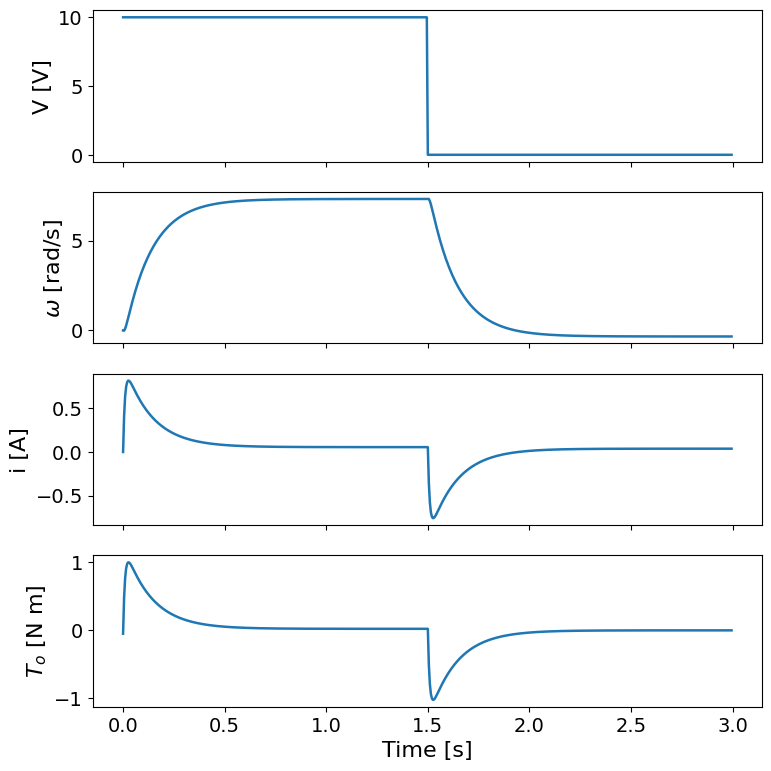

In [ ]:
# ── DC motor parameters ──────────────────────────────────────────
R  = 11.2;      L  = 0.1215    # Armature resistance [ohm], inductance [H]
J  = 0.022145;  b  = 0.002953  # Inertia [kg m^2], friction [N m s/rad]
k0 = 1.28;      V_ON = 10.0    # Coupling coefficient [N m/A], input voltage [V]
TL0 = 0.05                     # Load torque [N m]
dt  = 0.005                    # Integration step [s]
cycle_duration       = 3.0
voltage_on_duration  = 1.5

params = pd.DataFrame({
    'Symbol': ['R', 'L', 'J', 'b', 'k_T', 'V', 'T_L'],
    'Value' : [R, L, J, b, k0, V_ON, TL0],
    'Unit'  : ['ohm', 'H', 'kg m^2', 'N m s/rad', 'N m/A', 'V', 'N m'],
})
display(params)

t7, v7, w7, i7, to7 = simulate_motor(3.0 - dt)

fig, ax = plt.subplots(4, 1, figsize=(8, 8), sharex=True)
ax[0].plot(t7, v7);        ax[0].set_ylabel('V [V]')
ax[1].plot(t7, w7);        ax[1].set_ylabel(r'$\omega$ [rad/s]')
ax[2].plot(t7, i7);        ax[2].set_ylabel('i [A]')
ax[3].plot(t7, to7);       ax[3].set_ylabel(r'$T_o$ [N m]');  ax[3].set_xlabel('Time [s]')
plt.tight_layout();  plt.show()

## Component degradation

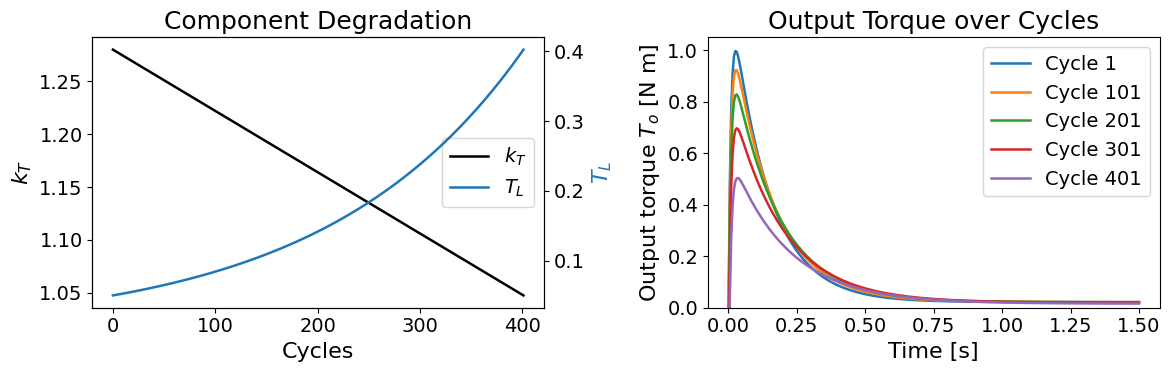

k_T at cycle 401 = 1.0475
T_L at cycle 401 = 0.4023
System performance at cycle 401 = 0.5038


In [ ]:
# Simultaneous degradation of k_T and T_L
alpha2    = -5.7974e-4;   beta2     =  5.2e-3
max_cycle = 401;          shown_cycles = [1, 101, 201, 301, 401]

def health_parameters(cycles):
    cycles = np.asarray(cycles, dtype=float)
    return k0 + alpha2 * cycles, TL0 * np.exp(beta2 * cycles)  # k_T, T_L

def pulse_torque_history(k_T, T_L):
    t, _, _, _, torque = simulate_motor(voltage_on_duration, k_T=k_T, T_L=T_L,
                                         periodic_voltage=False)
    return t, torque

cycles = np.arange(max_cycle + 1)
k_curve, tl_curve = health_parameters(cycles)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# Component degradation curves
ax[0].plot(cycles, k_curve, 'k', label=r'$k_T$')
ax[0].set_xlabel('Cycles');  ax[0].set_ylabel(r'$k_T$')
ax[0].set_title('Component Degradation')
ax_twin = ax[0].twinx()
ax_twin.plot(cycles, tl_curve, color='tab:blue', label=r'$T_L$')
ax_twin.set_ylabel(r'$T_L$', color='tab:blue')
lines1, lbl1 = ax[0].get_legend_handles_labels()
lines2, lbl2 = ax_twin.get_legend_handles_labels()
ax[0].legend(lines1 + lines2, lbl1 + lbl2, loc='center right')

# Output-torque degradation over cycles
for cycle in shown_cycles:
    k_T, T_L = health_parameters(cycle)
    t, torque = pulse_torque_history(float(k_T), float(T_L))
    ax[1].plot(t, torque, label=f'Cycle {cycle}')
ax[1].set_xlabel('Time [s]');  ax[1].set_ylabel(r'Output torque $T_o$ [N m]')
ax[1].set_title('Output Torque over Cycles')
ax[1].set_ylim(0, 1.05);  ax[1].legend(loc='upper right')
plt.tight_layout();  plt.show()

k_401, tl_401 = health_parameters(401)
s_401 = float(peak_torque_batch([k_401], [tl_401])[0])
print(f'k_T at cycle 401 = {k_401:.4f}')
print(f'T_L at cycle 401 = {tl_401:.4f}')
print(f'System performance at cycle 401 = {s_401:.4f}')

## EKF based state & health estimation



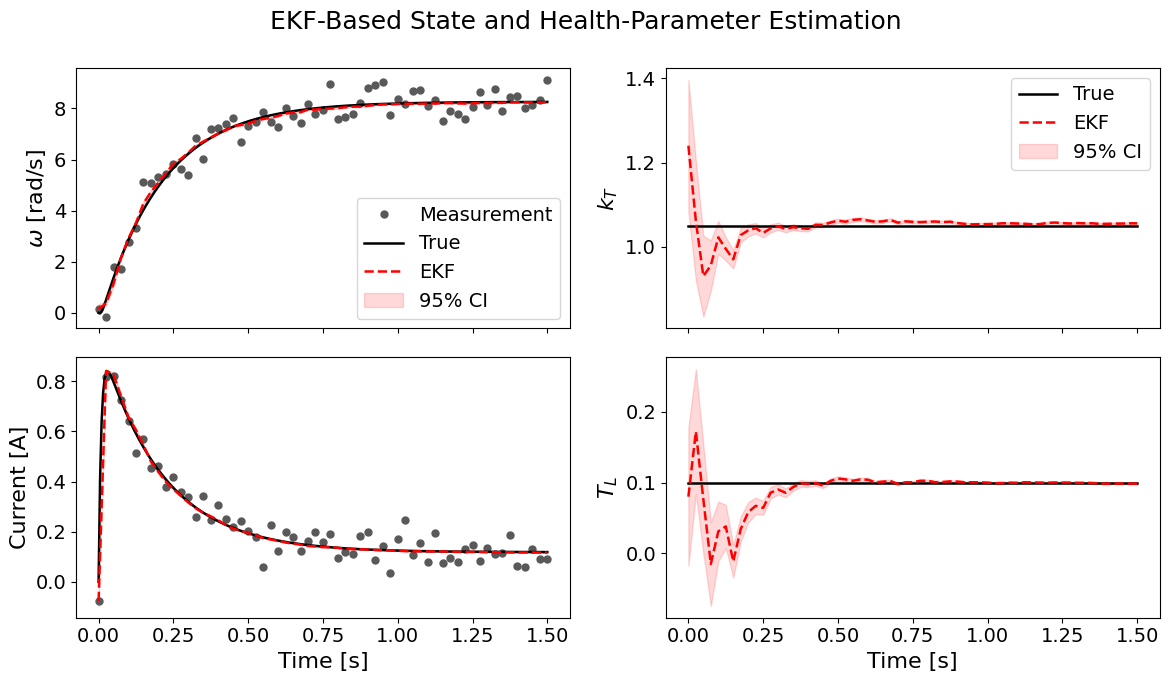

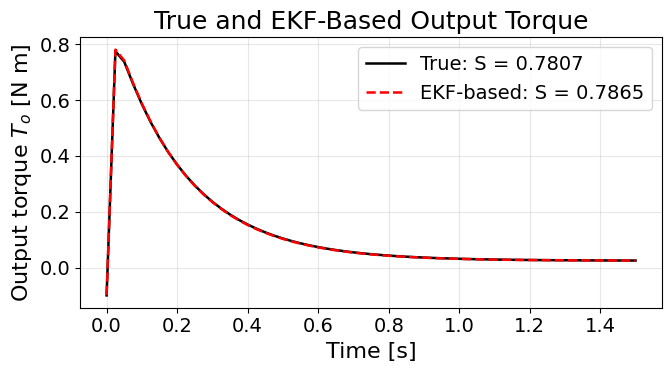

,Item,True,EKF estimate
0,k_T,1.0500,1.0555
1,T_L,0.1000,0.0983
2,System perf,0.7807,0.7865


In [ ]:
# True values used to generate virtual measurements
k_true, tl_true = 1.05, 0.10

def state_transition(x, voltage):
    omega, current, k_T, T_L = x
    return np.array([
        omega   + dt * (k_T * current - b * omega - T_L) / J,
        current + dt * (voltage - R * current - k_T * omega) / L,
        k_T, T_L
    ])

def transition_jacobian(x):
    omega, current, k_T, _ = x
    return np.array([
        [1 - dt*b/J,  dt*k_T/J,   dt*current/J, -dt/J],
        [-dt*k_T/L,  1 - dt*R/L, -dt*omega/L,    0   ],
        [0,          0,           1,              0   ],
        [0,          0,           0,              1   ]
    ])

def run_ekf(k_true, tl_true):
    t, voltage, omega_true, current_true, torque_true = simulate_motor(
        voltage_on_duration, k_T=k_true, T_L=tl_true, periodic_voltage=False
    )
    rng = np.random.default_rng(42)

    sigma_omega = 0.50
    sigma_current = 0.05

    z = np.column_stack([
        omega_true   + rng.normal(0, sigma_omega, len(t)),
        current_true + rng.normal(0, sigma_current, len(t))
    ])

    H  = np.array([[1, 0, 0, 0], [0, 1, 0, 0]])
    Q  = np.diag([1e-9, 1e-9, 1e-9, 1e-9])
    Rm = np.diag([0.10**2, 0.01**2])
    x  = np.array([0.0, 0.0, 1.24, 0.08])
    P  = np.diag([0.5**2, 0.1**2, 0.08**2, 0.05**2])
    x_hist = np.zeros((len(t), 4));  p_hist = np.zeros((len(t), 4, 4))
    for n in range(len(t)):
        if n > 0:
            F = transition_jacobian(x);  x = state_transition(x, voltage[n-1])
            P = F @ P @ F.T + Q
        S_cov = H @ P @ H.T + Rm;  K = P @ H.T @ np.linalg.inv(S_cov)
        x = x + K @ (z[n] - H @ x);  P = (np.eye(4) - K @ H) @ P
        x_hist[n] = x;  p_hist[n] = P
    return t, z, omega_true, current_true, torque_true, x_hist, p_hist

t, z, omega_true, current_true, torque_true, x_hist, p_hist = run_ekf(k_true, tl_true)
ci = 1.96 * np.sqrt(np.maximum(np.diagonal(p_hist, axis1=1, axis2=2), 0))
k_est, tl_est = x_hist[-1, 2:4]

# Plot state and parameter estimation
fig, ax = plt.subplots(2, 2, figsize=(12, 7), sharex=True, dpi=100)

for row, col, true_vals, meas, ylabel, title in [
    (0, 0, omega_true,   z[:, 0], r'$\omega$ [rad/s]', None),
    (1, 0, current_true, z[:, 1], 'Current [A]', None),
    (0, 1, np.full(len(t), k_true), None, r'$k_T$', None),
    (1, 1, np.full(len(t), tl_true), None, r'$T_L$', None),
]:
    a = ax[row, col]
    skip = 5
    if meas is not None:
        a.plot(t[::skip], meas[::skip], '.', color='0.35', ms=10, label='Measurement')
    a.plot(t, true_vals, 'k', label='True')
    idx = [[0, 2], [1, 3]][row][col]
    a.plot(t[::skip], x_hist[::skip, idx], 'r--', label='EKF')
    a.fill_between(t[::skip], x_hist[::skip, idx] - ci[::skip, idx],
                      x_hist[::skip, idx] + ci[::skip, idx], color='red', alpha=0.15, label='95% CI')
    a.set_ylabel(ylabel)
    if row == 1: a.set_xlabel('Time [s]')

ax[0, 0].legend()
ax[0, 1].legend()
plt.suptitle('EKF-Based State and Health-Parameter Estimation')
plt.tight_layout();  plt.show()

# Output torque from EKF estimates vs true
_, _, _, _, torque_est = simulate_motor(voltage_on_duration, k_T=k_est, T_L=tl_est,
                                         periodic_voltage=False)
s_true, s_est = np.max(torque_true), np.max(torque_est)

plt.figure(figsize=(7, 4))
plt.plot(t[::skip], torque_true[::skip], 'k',  label=f'True: S = {s_true:.4f}')
plt.plot(t[::skip], torque_est[::skip],  'r--', label=f'EKF-based: S = {s_est:.4f}')
plt.xlabel('Time [s]');  plt.ylabel(r'Output torque $T_o$ [N m]')
plt.title('True and EKF-Based Output Torque')
plt.legend();  plt.grid(True, alpha=0.3);  plt.tight_layout();  plt.show()

display(HTML('<h4>Parameter Summary</h4>'))
display(pd.DataFrame({'Item': ['k_T', 'T_L', 'System perf'],
                      'True': [k_true, tl_true, s_true],
                      'EKF estimate': [k_est, tl_est, s_est]}).round(4))

## Current health and restoration

,k_T HI,T_L HI,System HI
Current,0.3508,0.0508,0.7050
Restore k_T,0.0000,0.0508,0.1460
Restore T_L,0.3508,0.0000,0.5574


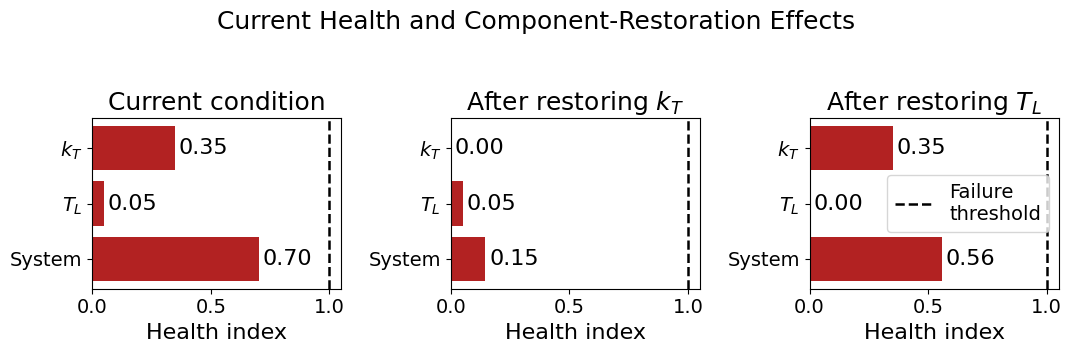

In [ ]:
# Health-index reference values
k_normal, k_fault  = k0, k0 / 2
tl_normal, tl_fault = TL0, 1.0

# Use EKF estimates as the current component values
k_current, tl_current = k_est, tl_est

def performance(k_T, T_L):
    """Peak output torque (scalar) for the given component parameters."""
    return float(peak_torque_batch([k_T], [T_L])[0])

s0 = performance(k_normal, tl_normal)  # nominal reference

def health_indices(k_T, T_L):
    s_ratio = performance(k_T, T_L) / s0
    hi_k    = (k_normal - k_T)   / (k_normal - k_fault)
    hi_tl   = (T_L - tl_normal)  / (tl_fault - tl_normal)
    hi_sys  = (1 - s_ratio) / (1 - 0.7)
    return np.array([hi_k, hi_tl, hi_sys]), s_ratio

health_current, _  = health_indices(k_current, tl_current)
health_after_k,  _ = health_indices(k_normal,  tl_current)
health_after_tl, _ = health_indices(k_current, tl_normal)

health_summary = pd.DataFrame(
    np.vstack([health_current, health_after_k, health_after_tl]),
    index=['Current', 'Restore k_T', 'Restore T_L'],
    columns=['k_T HI', 'T_L HI', 'System HI']
)
display(HTML('<h4>Health Summary</h4>'));  display(health_summary.round(4))

values_all = [health_current, health_after_k, health_after_tl]
titles     = ['Current condition', r'After restoring $k_T$', r'After restoring $T_L$']
labels     = [r'$k_T$', r'$T_L$', 'System']
x_max      = max(1.05, np.max(values_all) * 1.15)

fig, ax = plt.subplots(1, 3, figsize=(11, 3.5), dpi=100, sharex=True)
for axis, values, title in zip(ax, values_all, titles):
    bars = axis.barh(labels, values, color='firebrick')
    axis.axvline(1, color='black', linestyle='--', label='Failure\nthreshold')
    axis.set_xlim(0, x_max);  axis.set_xlabel('Health index')
    axis.set_title(title);  axis.invert_yaxis();  axis.grid(False)
    for bar, value in zip(bars, values):
        axis.text(value + 0.015, bar.get_y() + bar.get_height()/2,
                  f'{value:.2f}', va='center')
ax[-1].legend(loc='center right')
plt.suptitle('Current Health and Component-Restoration Effects', y=1.02)
plt.tight_layout();  plt.show()

# Robot Fault Diagnosis

Reproduces paper: "System-Level Fault Diagnosis for an Industrial Robot Using Bayesian Networks", Choi and Lee 2022, Proceedings of the Institution of Mechanical Engineers, Part O.

Components: Harmonic Drive (HD) and Timing Belt (TB).  
HD severity levels: Lv0 (normal) – Lv2 (most degraded).  
TB severity levels: Lv0 – Lv3.

### Signals under normal and fault conditions

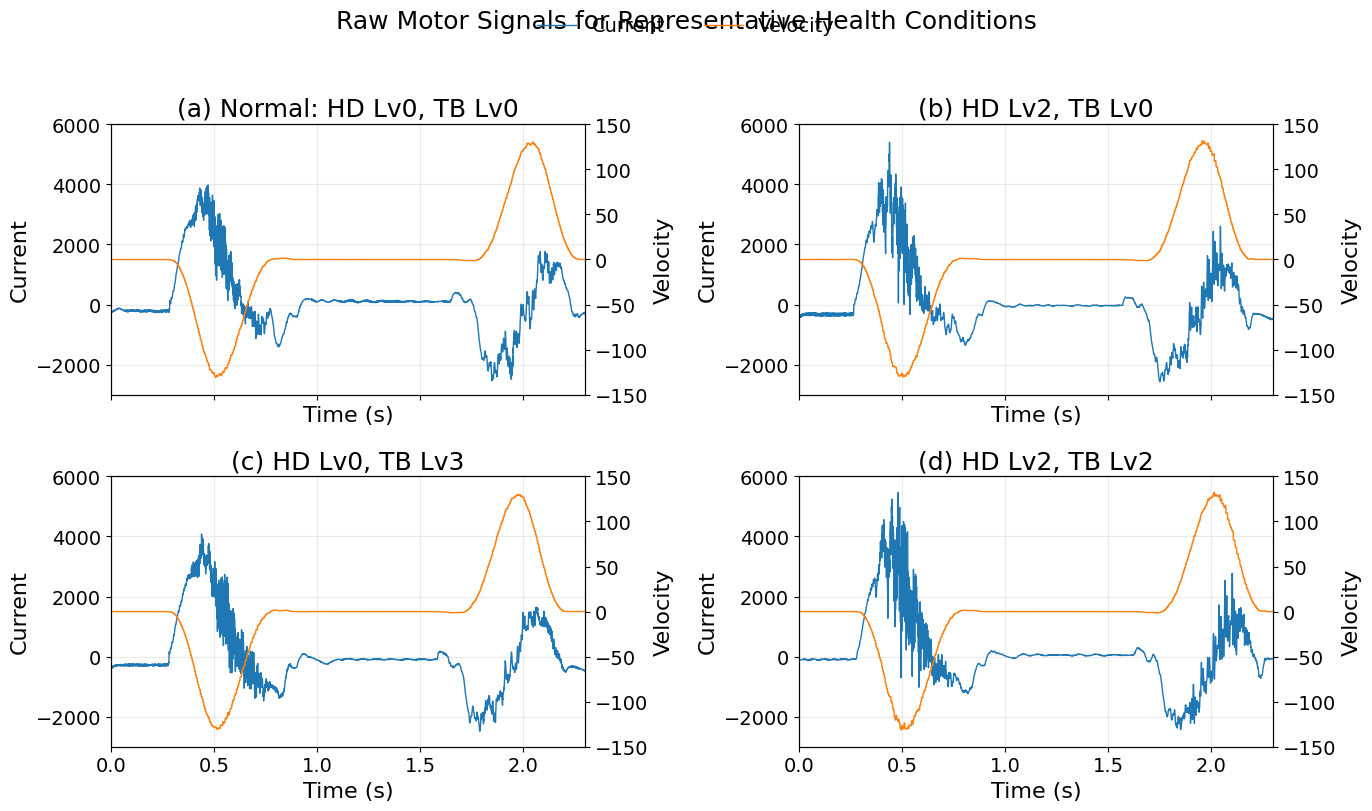

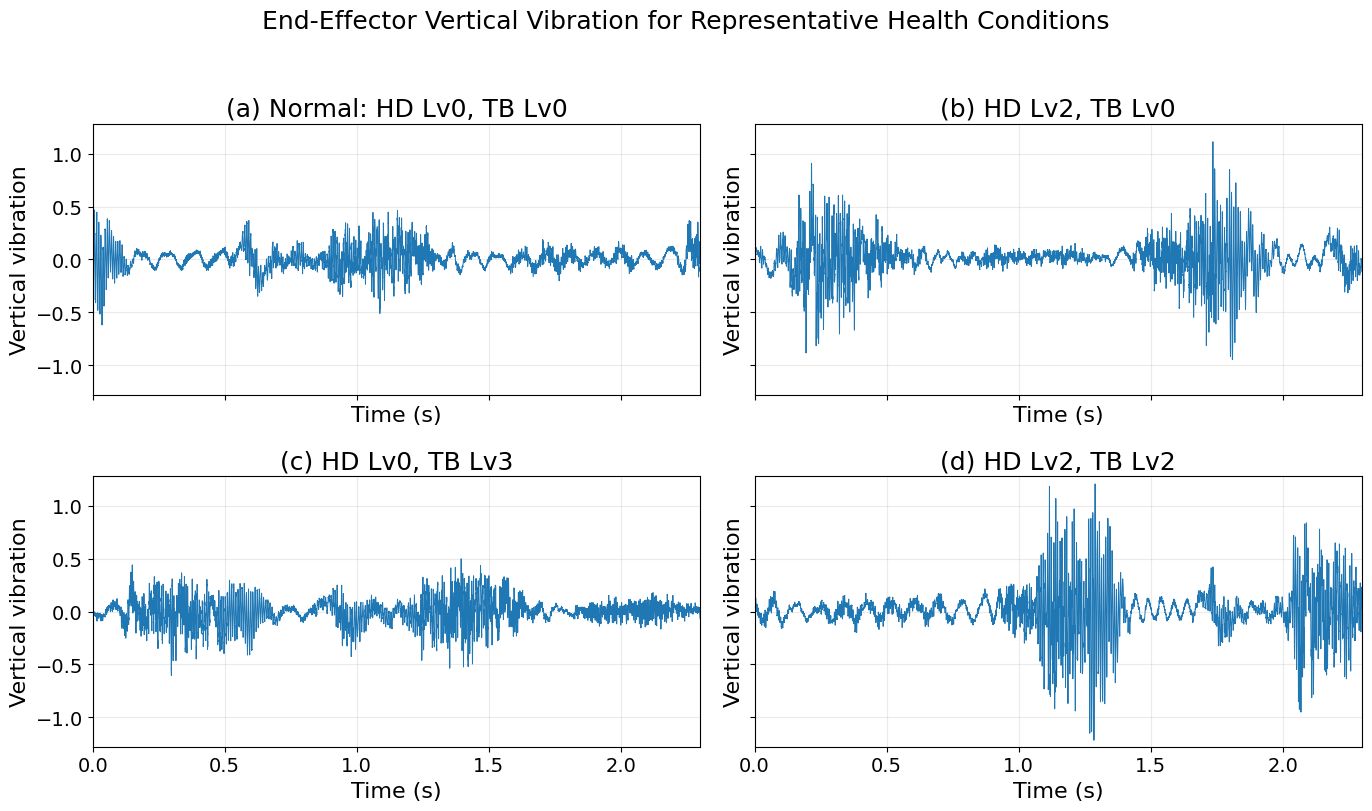

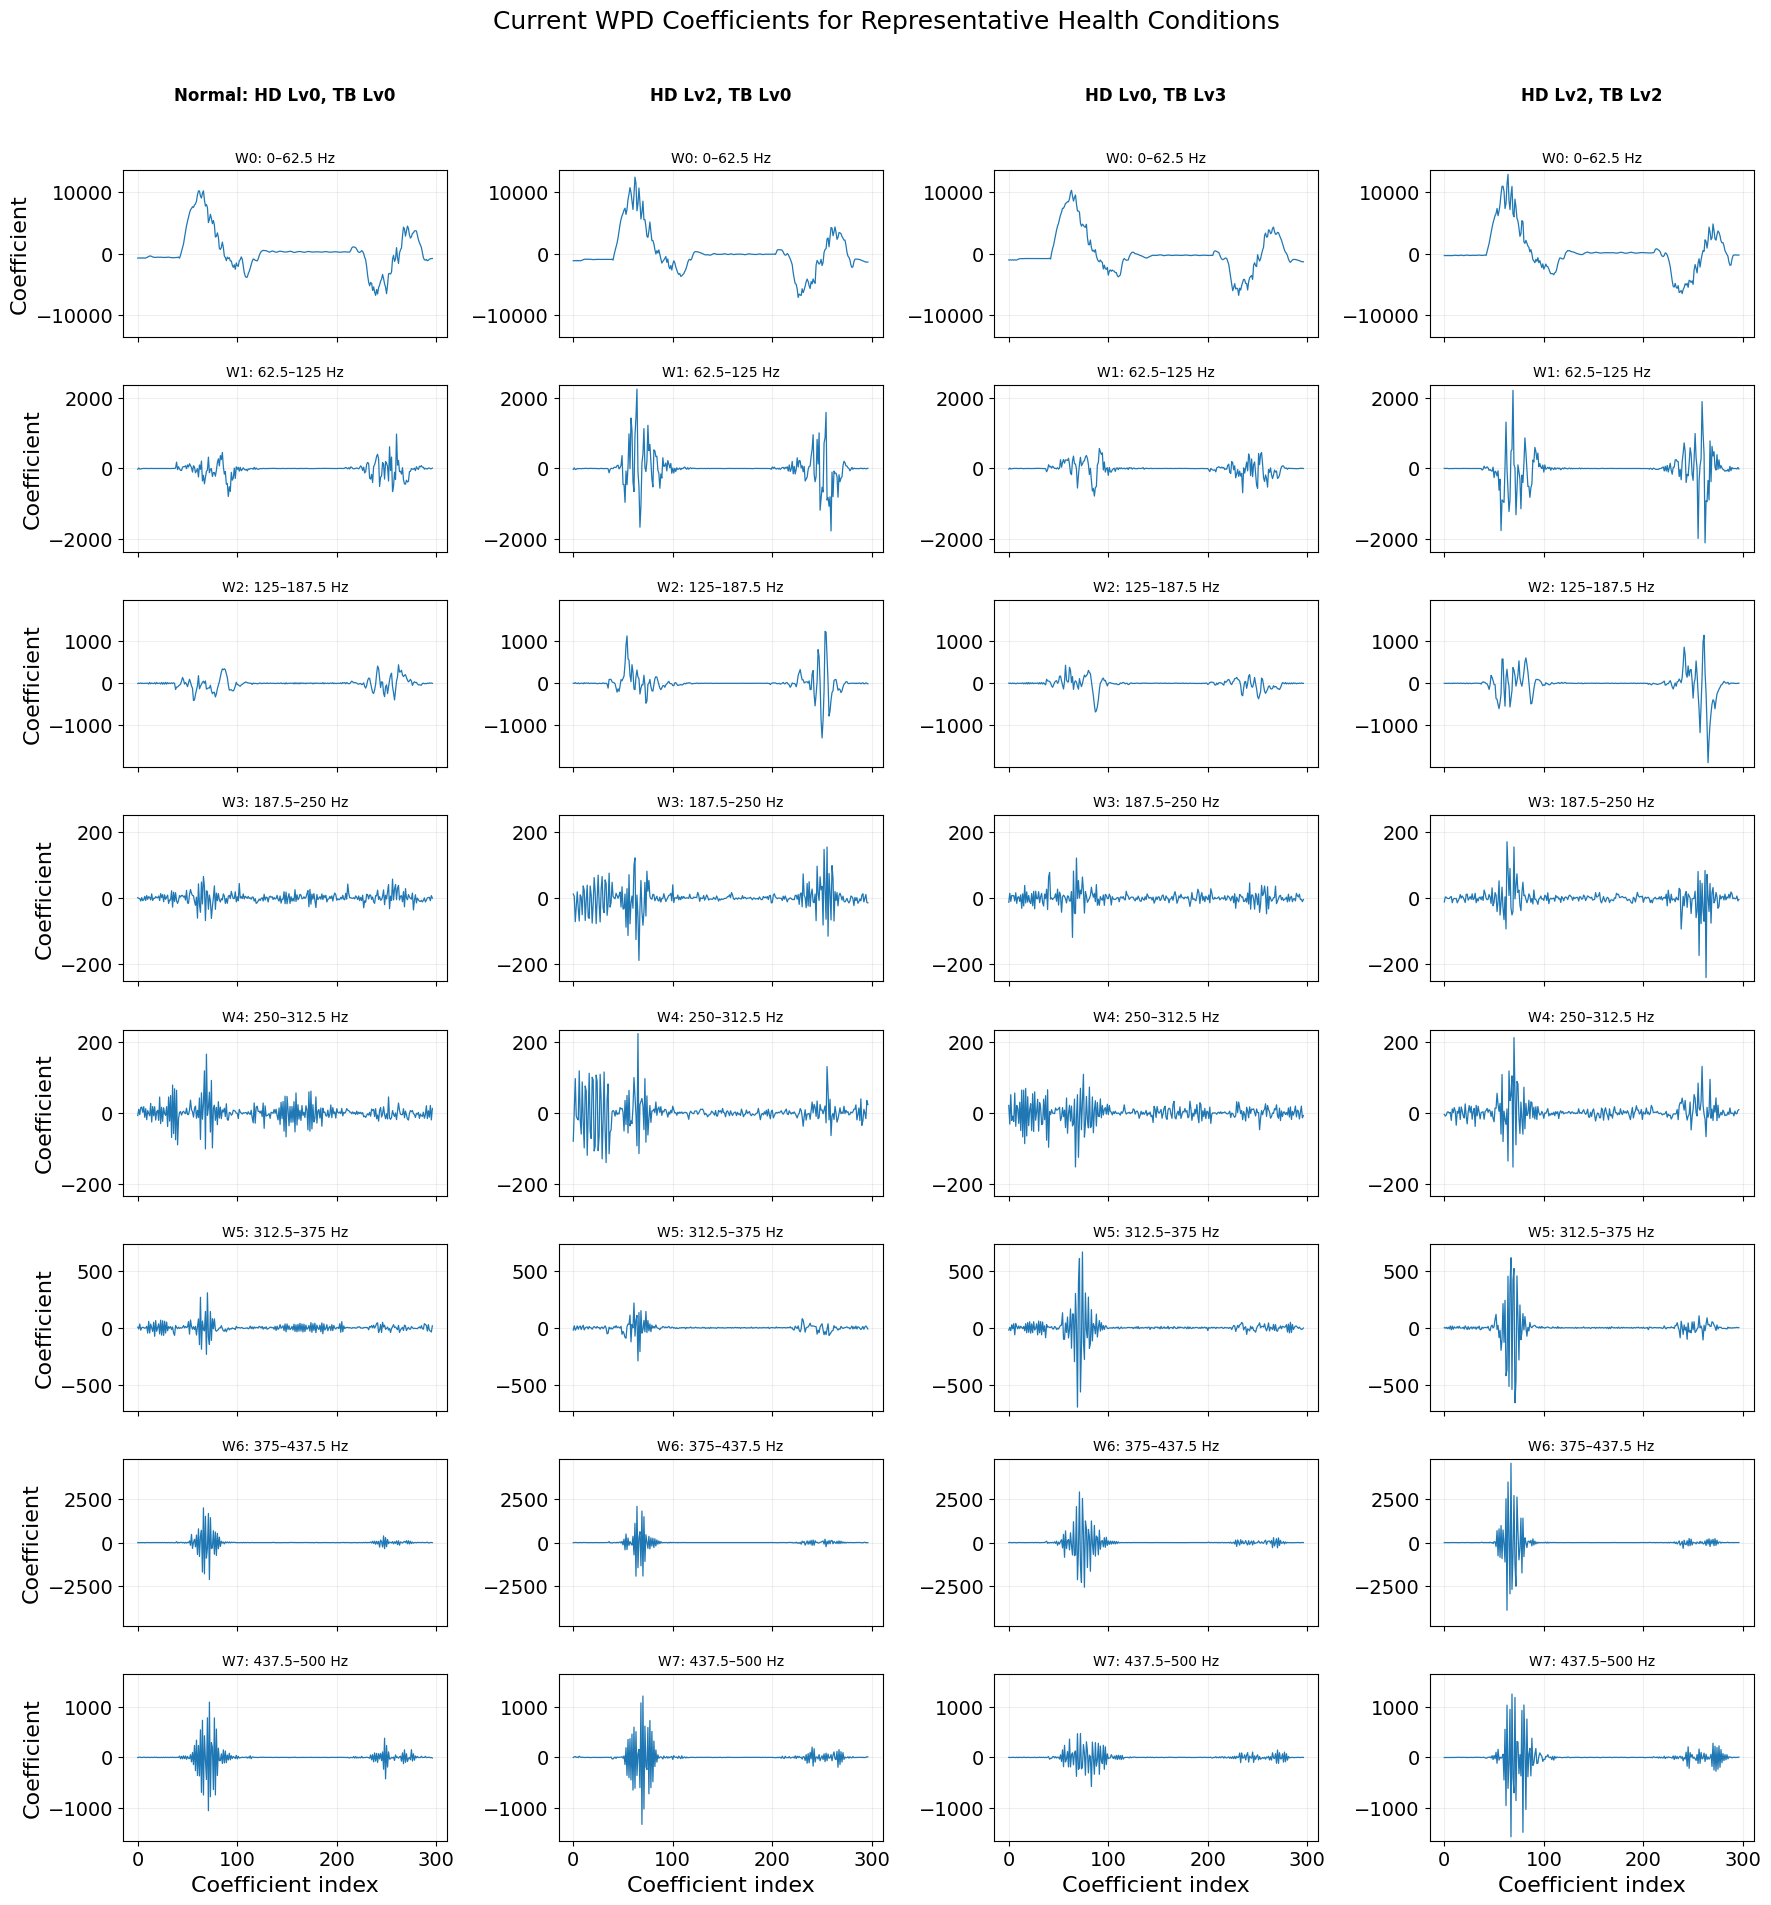

In [ ]:
# Load the four comparison cases using load_case defined in Shared utility functions
case_data  = {name: load_case(name) for name, _ in COMPARISON_CASES}
time_robot = np.arange(N_ROBOT) / FS_ROBOT

# ── Raw motor current and velocity ───────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
for panel, (ax, (file_name, condition)) in enumerate(zip(axes.flat, COMPARISON_CASES)):
    segment   = case_data[file_name][0]
    ax_vel    = ax.twinx()
    cur_line  = ax.plot(time_robot, segment[:, 0], color='tab:blue', lw=1, label='Current')[0]
    vel_line  = ax_vel.plot(time_robot, segment[:, 4], color='tab:orange', lw=1, label='Velocity')[0]
    ax.set(xlim=(0, DURATION), ylim=(-3000, 6000),
           xlabel='Time (s)', ylabel='Current',
           title=f'({chr(97 + panel)}) {condition}')
    ax_vel.set_ylim(-150, 150);  ax_vel.set_ylabel('Velocity')
    ax.grid(alpha=0.25)
fig.legend([cur_line, vel_line], ['Current', 'Velocity'],
           loc='upper center', ncol=2, frameon=False)
fig.suptitle('Raw Motor Signals for Representative Health Conditions', y=1.02)
fig.tight_layout();  plt.show()

# ── Vertical vibration ────────────────────────────────────────
vib_limit = 1.05 * max(np.max(np.abs(case_data[name][1]))
                        for name, _ in COMPARISON_CASES)
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True, sharey=True)
for panel, (ax, (file_name, condition)) in enumerate(zip(axes.flat, COMPARISON_CASES)):
    vibration = case_data[file_name][1]
    fs_vib    = case_data[file_name][2]
    t_vib     = np.arange(len(vibration)) / fs_vib
    ax.plot(t_vib, vibration, color='tab:blue', lw=0.7)
    ax.set(xlim=(0, DURATION), ylim=(-vib_limit, vib_limit),
           xlabel='Time (s)', ylabel='Vertical vibration',
           title=f'({chr(97 + panel)}) {condition}')
    ax.grid(alpha=0.25)
fig.suptitle('End-Effector Vertical Vibration for Representative Health Conditions', y=1.02)
fig.tight_layout();  plt.show()

# ── Current WPD coefficients ──────────────────────────────────
frequency_bands = [
    (0, 62.5), (62.5, 125), (125, 187.5), (187.5, 250),
    (250, 312.5), (312.5, 375), (375, 437.5), (437.5, 500)
]
case_wpd = {}
for file_name, _ in COMPARISON_CASES:
    wp = pywt.WaveletPacket(case_data[file_name][0][:, 0], wavelet='db6',
                             mode='symmetric', maxlevel=3)
    case_wpd[file_name] = [np.asarray(node.data, dtype=float)
                            for node in wp.get_level(3, order='freq')]

fig, axes = plt.subplots(8, 4, figsize=(18, 19), sharex='col')
for band, (low, high) in enumerate(frequency_bands):
    limit = max(1, 1.05 * max(np.max(np.abs(case_wpd[name][band]))
                               for name, _ in COMPARISON_CASES))
    for case, (file_name, condition) in enumerate(COMPARISON_CASES):
        ax = axes[band, case]
        ax.plot(case_wpd[file_name][band], color='tab:blue', lw=0.9)
        ax.set_ylim(-limit, limit)
        ax.set_title(f'W{band}: {low:g}–{high:g} Hz', fontsize=10)
        ax.grid(alpha=0.2)
        if case == 0:  ax.set_ylabel('Coefficient')
        if band == 0:
            ax.text(0.5, 1.42, condition, transform=ax.transAxes,
                    ha='center', fontsize=12, fontweight='bold')
        if band == 7: ax.set_xlabel('Coefficient index')
fig.suptitle('Current WPD Coefficients for Representative Health Conditions', y=1.005)
fig.tight_layout();  plt.show()

## Feature Extraction by WPD

Extracts 20 operation segments per file, applies WPD to current (col 0) and velocity (col 4), and computes 112 features per signal (8 sub-bands × 14 features each).

### Verify operation segmentation using one file

The GPL signal (column 11) is a square-wave gate: each rising edge marks the start of a new robot operation. Skip the first two operations (warm-up) and use the next 20.

In [ ]:
raw_files = sorted(path for path in ROBOT_ROOT.glob('*.mat')
                   if RAW_FILE_PATTERN.fullmatch(path.name))
if len(raw_files) != 55:
    raise ValueError(f'Expected 55 raw files, but found {len(raw_files)}.')
print('Number of raw files:', len(raw_files))

example = loadmat(raw_files[0], variable_names=['robot'])
robot   = np.asarray(example['robot'], dtype=float)
gpl     = robot[:, 11]
rising_points = np.where(np.diff(gpl) == 1)[0]

print('robot shape:', robot.shape)
print('GPL rising edges:', len(rising_points))

segments = []
for operation in range(20):
    start   = rising_points[operation + 2]
    stop    = rising_points[operation + 3] + 1
    segment = robot[start:stop, :]
    if len(segment) < N_ROBOT:
        raise ValueError(f'Operation {operation + 1}: only {len(segment)} samples.')
    segments.append(segment[:N_ROBOT, :])

segments = np.stack(segments)
print('Segment array:', segments.shape)

Number of raw files: 55
robot shape: (59998, 12)
GPL rising edges: 24
Segment array: (20, 2300, 12)


### Extract WPD features from all raw files

[01/55] 0000_00_01.mat  0.8 s
[02/55] 0000_00_02.mat  1.9 s
[03/55] 0000_00_03.mat  2.7 s
[04/55] 0000_00_04.mat  4.3 s
[05/55] 0000_00_05.mat  5.2 s
[06/55] 0000_01_01.mat  6.0 s
[07/55] 0000_01_02.mat  7.2 s
[08/55] 0000_01_03.mat  8.4 s
[09/55] 0000_01_04.mat  9.4 s
[10/55] 0000_01_05.mat  10.6 s
[11/55] 0000_02_01.mat  11.1 s
[12/55] 0000_02_02.mat  12.2 s
[13/55] 0000_02_03.mat  13.9 s
[14/55] 0000_02_04.mat  15.1 s
[15/55] 0000_02_05.mat  16.1 s
[16/55] 0100_00_01.mat  17.2 s
[17/55] 0100_00_02.mat  18.4 s
[18/55] 0100_00_03.mat  19.5 s
[19/55] 0100_00_04.mat  20.5 s
[20/55] 0100_00_05.mat  21.9 s
[21/55] 0100_01_01.mat  22.8 s
[22/55] 0100_01_02.mat  24.0 s
[23/55] 0100_01_03.mat  25.8 s
[24/55] 0100_01_04.mat  26.9 s
[25/55] 0100_01_05.mat  28.2 s
[26/55] 0100_02_01.mat  29.5 s
[27/55] 0100_02_02.mat  30.4 s
[28/55] 0100_02_03.mat  31.3 s
[29/55] 0100_02_04.mat  32.4 s
[30/55] 0100_02_05.mat  33.5 s
[31/55] 0200_00_01.mat  34.5 s
[32/55] 0200_00_02.mat  35.6 s
[33/55] 0200_00_0

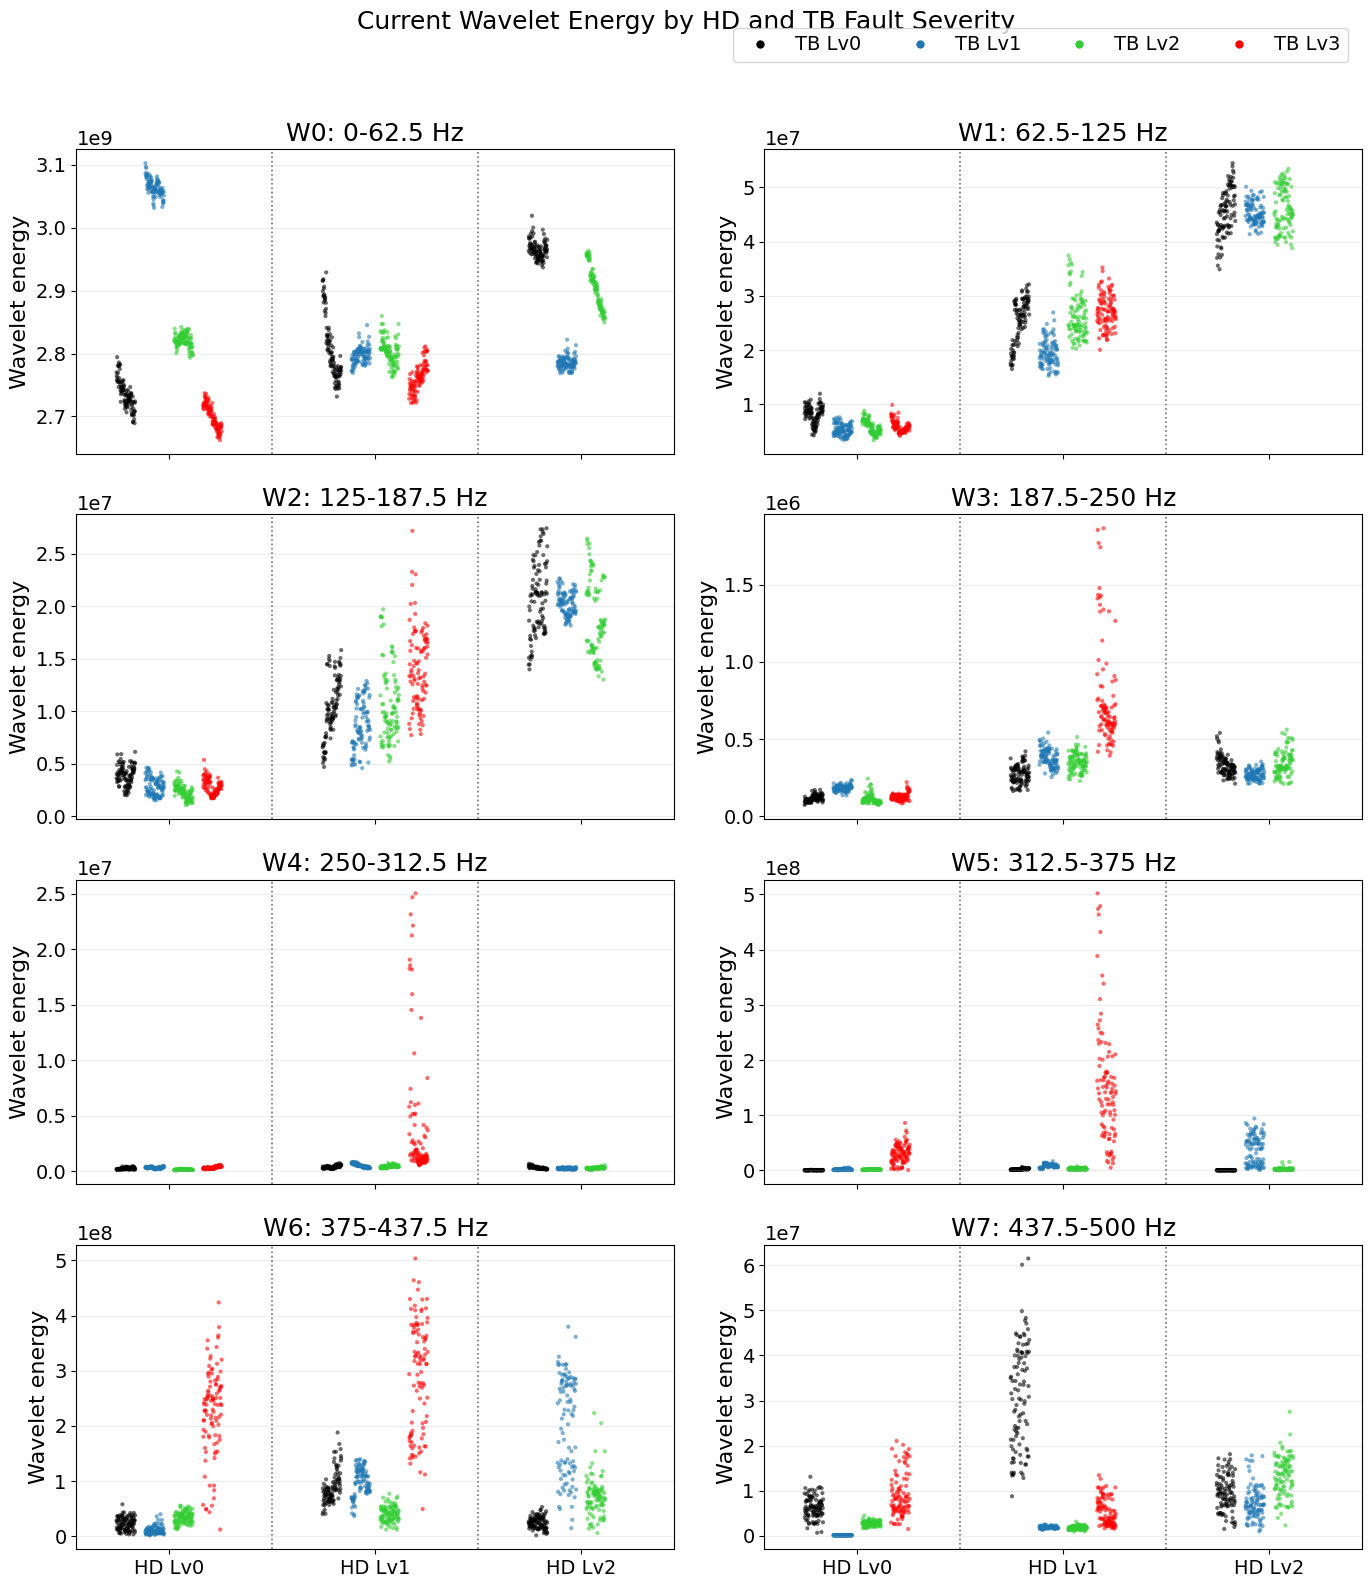

In [ ]:
feature_rows    = []
operation_labels = []
feature_names   = None
start_time      = time.time()

for file_number, file_path in enumerate(raw_files, start=1):
    file_label  = parse_raw_file_name(file_path)
    data        = loadmat(file_path, variable_names=['robot'])
    robot       = np.asarray(data['robot'], dtype=float)
    gpl         = robot[:, 11]
    rising_pts  = np.where(np.diff(gpl) == 1)[0]

    if len(rising_pts) < OPERATIONS_PER_FILE + 3:
        raise ValueError(f'{file_path.name}: only {len(rising_pts)} GPL rising edges.')

    for operation in range(OPERATIONS_PER_FILE):
        start   = rising_pts[operation + 2]
        stop    = rising_pts[operation + 3] + 1
        segment = robot[start:stop, :]
        if len(segment) < SAMPLES_PER_OPERATION:
            raise ValueError(f'{file_path.name}, op {operation+1}: '
                             f'only {len(segment)} samples.')
        segment = segment[:SAMPLES_PER_OPERATION, :]

        cur_feats, cur_names = wpd_features(segment[:, 0])
        vel_feats, vel_names = wpd_features(segment[:, 4])
        feature_rows.append(np.concatenate([cur_feats, vel_feats]))
        operation_labels.append(file_label)

        if feature_names is None:
            feature_names = ([f'Cur-{n}' for n in cur_names]
                           + [f'Vel-{n}' for n in vel_names])

    print(f'[{file_number:02d}/{len(raw_files)}] {file_path.name}  '
          f'{time.time() - start_time:.1f} s')

feat_robot = np.vstack(feature_rows)
labseg     = np.vstack(operation_labels).astype(np.uint8)
feat_name  = np.asarray(feature_names, dtype=object).reshape(1, -1)
fs_r       = np.array([[FS_ROBOT]], dtype=np.uint16)
print(f'\nfeat_robot: {feat_robot.shape}  |  labseg: {labseg.shape}')

# ── Wavelet energy visualisation (Figure 10 style) ───────────
natural_paths   = ['aaa', 'aad', 'ada', 'add', 'daa', 'dad', 'dda', 'ddd']
frequency_paths = ['aaa', 'aad', 'add', 'ada', 'dda', 'ddd', 'dad', 'daa']
freq_from_nat   = [natural_paths.index(p) for p in frequency_paths]
nat_we_cols     = np.arange(13, 112, 14)          # wavelet-energy column in natural order
freq_we_cols    = nat_we_cols[freq_from_nat]
current_we      = feat_robot[:, freq_we_cols]

hd_level   = labseg[:, 2].astype(int)
tb_level   = labseg[:, 0].astype(int)
tb_colors  = {0: 'black', 1: 'tab:blue', 2: 'limegreen', 3: 'red'}

fig, axes = plt.subplots(4, 2, figsize=(14, 16), sharex=True)
for band_index, ax in enumerate(axes.flat):
    for hd in range(3):
        for tb in range(4):
            sel = np.flatnonzero((hd_level == hd) & (tb_level == tb))
            if sel.size == 0: continue
            center = hd + (tb - 1.5) * 0.14
            spread = np.linspace(-0.045, 0.045, sel.size)
            ax.scatter(center + spread, current_we[sel, band_index],
                       s=9, color=tb_colors[tb], alpha=0.58, edgecolors='none')
    ax.axvline(0.5, color='0.45', ls=':', lw=1.2)
    ax.axvline(1.5, color='0.45', ls=':', lw=1.2)
    low, high = frequency_bands[band_index]
    ax.set_title(f'W{band_index}: {low:g}-{high:g} Hz')
    ax.set_ylabel('Wavelet energy');  ax.grid(axis='y', alpha=0.22)
    ax.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))
    ax.set_xlim(-0.45, 2.45);  ax.set_xticks([0, 1, 2])
    ax.set_xticklabels(['HD Lv0', 'HD Lv1', 'HD Lv2'])

legend_handles = [Line2D([0], [0], marker='o', linestyle='none', markersize=6,
                          markerfacecolor=tb_colors[lv], markeredgecolor='none',
                          label=f'TB Lv{lv}') for lv in range(4)]
fig.legend(handles=legend_handles, loc='upper right', ncol=4,
           frameon=True, bbox_to_anchor=(0.98, 0.99))
fig.suptitle('Current Wavelet Energy by HD and TB Fault Severity', y=0.995)
fig.tight_layout(rect=(0, 0, 1, 0.97));  plt.show()

### Save the feature dataset

In [ ]:
expected_shapes = {'feat_robot': (1100, 224), 'feat_name': (1, 224), 'labseg': (1100, 4)}
for name, expected in expected_shapes.items():
    actual = eval(name + '.shape')
    if actual != expected:
        raise ValueError(f'{name}: expected {expected}, obtained {actual}')

output_path = ROBOT_ROOT / 'Features_robot.mat'
savemat(output_path,
        {'feat_robot': feat_robot, 'feat_name': feat_name,
         'fs_r': fs_r, 'labseg': labseg},
        do_compression=True)
print('Saved:', output_path)

Saved: /content/drive/MyDrive/PHM Practice/Datasets/Robot/Features_robot.mat


## Feature Selection by Spearman & FDR

Features are ranked separately for HD and TB by combining Spearman correlation and Fisher Discriminant Ratio (FDR). The composite score is `alpha * Spearman + (1-alpha) * FDR` with `alpha = 0.8`.

### Functions for scoring

In [ ]:
def calculate_fdr(means, standard_deviations):
    """Fisher Discriminant Ratio: between-class to within-class variance ratio."""
    means = np.asarray(means, dtype=float)
    standard_deviations = np.asarray(standard_deviations, dtype=float)
    mean_avg = np.mean(means)
    num = np.sum((mean_avg - means)**2)
    den = np.sum(standard_deviations**2)
    return num / den if den > 0 else 0.0

def minmax(values):
    """Min-max normalisation to [0, 1]. Returns zeros if span is zero."""
    values = np.asarray(values, dtype=float)
    span   = np.nanmax(values) - np.nanmin(values)
    return np.zeros_like(values) if span == 0 else (values - np.nanmin(values)) / span

def rank_features(features, labels, target_column, fixed_column, alpha=0.8):
    """Rank features by Spearman + FDR score for one health component.
    Input : features      - (n_samples, n_features) raw feature matrix
            labels        - (n_samples, n_label_cols) integer label matrix
            target_column - column of the component to be assessed
            fixed_column  - column of the component held fixed during scoring
            alpha         - weight on Spearman score (1-alpha on FDR)
    Output: dict with keys 'normalized_features', 'spearman', 'fdr', 'score', 'order'
    """
    features = np.asarray(features, dtype=float)
    labels   = np.asarray(labels)
    feat_mean = np.nanmean(features, axis=0)
    feat_std  = np.nanstd(features,  axis=0, ddof=1)
    normalized = np.divide(features - feat_mean, feat_std,
                           out=np.zeros_like(features), where=feat_std > 0)
    spearman_total = np.zeros(features.shape[1])
    fdr_total      = np.zeros(features.shape[1])
    for fixed_level in np.unique(labels[:, fixed_column]):
        idx    = labels[:, fixed_column] == fixed_level
        target = labels[idx, target_column]
        if np.unique(target).size < 2: continue
        for j in range(features.shape[1]):
            vals = normalized[idx, j]
            corr = spearmanr(target, vals).statistic
            if np.isfinite(corr): spearman_total[j] += corr
            means = [np.mean(vals[target == lv]) for lv in np.unique(target)]
            stds  = [np.std(vals[target == lv], ddof=1) for lv in np.unique(target)]
            fdr_total[j] += calculate_fdr(means, stds)
    score = alpha * minmax(np.abs(spearman_total)) + (1 - alpha) * minmax(np.abs(fdr_total))
    order = np.argsort(score)[::-1]
    return {'normalized_features': normalized, 'spearman': spearman_total,
            'fdr': fdr_total, 'score': score, 'order': order}

feature_name_list = [str(v) for v in np.asarray(feat_name).reshape(-1)]

### Feature ranking for HD & TB

In [ ]:
hd_result = rank_features(feat_robot, labseg, target_column=2, fixed_column=0, alpha=0.8)
tb_result = rank_features(feat_robot, labseg, target_column=0, fixed_column=2, alpha=0.8)

def make_rank_table(result):
    return pd.DataFrame({
        'Rank':     np.arange(1, len(result['order']) + 1),
        'Feature':  [feature_name_list[i] for i in result['order']],
        'Score':    result['score'][result['order']],
        'Spearman': result['spearman'][result['order']],
        'FDR':      result['fdr'][result['order']],
    })

print('HD feature ranking (top 10):')
display(make_rank_table(hd_result).head(10))
print('TB feature ranking (top 10):')
display(make_rank_table(tb_result).head(10))

HD feature ranking (top 10):


,Rank,Feature,Score,Spearman,FDR
0,1,Cur-W1-STD,1.000000,3.694479,152.822517
1,2,Cur-W1-RMS,0.998816,3.694479,151.917716
2,3,Cur-WE1,0.984849,3.694479,141.245551
3,4,Cur-W1-SE,0.981317,-3.694479,138.547166
4,5,Cur-W1-P2P,0.871680,3.684061,56.501581
5,6,Cur-W0-KUR,0.861820,3.117703,142.956123
6,7,Cur-W3-STD,0.846987,3.661622,41.357595
7,8,Cur-W3-RMS,0.845972,3.660019,40.848012
8,9,Cur-WE3,0.842918,3.660019,38.514443
9,10,Cur-W3-SE,0.842428,-3.661999,37.811303


TB feature ranking (top 10):


,Rank,Feature,Score,Spearman,FDR
0,1,Vel-W0-SF,0.859504,-2.496198,25.977197
1,2,Cur-W7-MF,0.683255,2.073531,8.191978
2,3,Cur-W7-Peak(Max),0.669244,2.016884,10.002724
3,4,Cur-W7-P2P,0.663553,1.996302,10.398726
4,5,Cur-W7-SF,0.649177,1.949484,10.675059
5,6,Cur-W7-RMS,0.644852,1.935336,10.767247
6,7,Cur-W7-STD,0.644815,1.935278,10.759241
7,8,Cur-W7-SE,0.632530,-1.940497,4.666975
8,9,Cur-WE7,0.631740,1.935336,5.044238
9,10,Cur-W7-IF,0.606555,1.854351,5.383624


### Selected features

The paper selects the threshold at the largest meaningful gap in the rounded-score distribution. Features above the threshold are kept; highly correlated pairs are pruned.

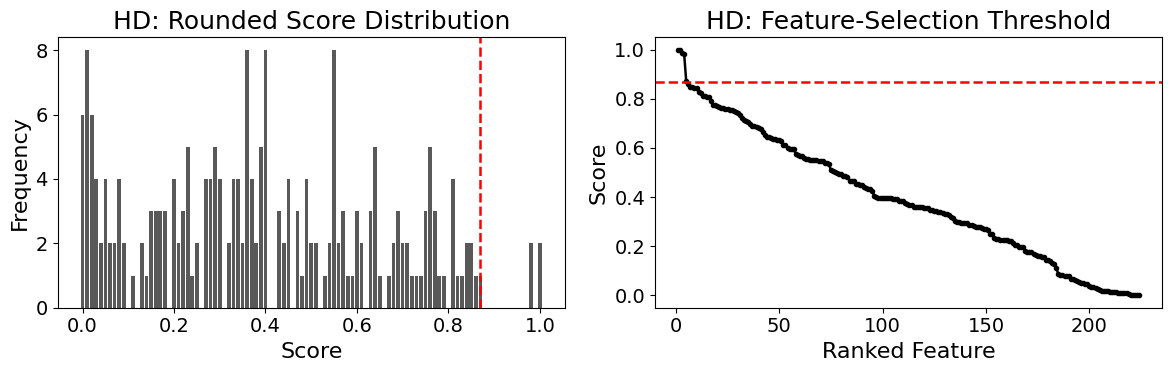

HD threshold: 0.87  |  selected: 5 features


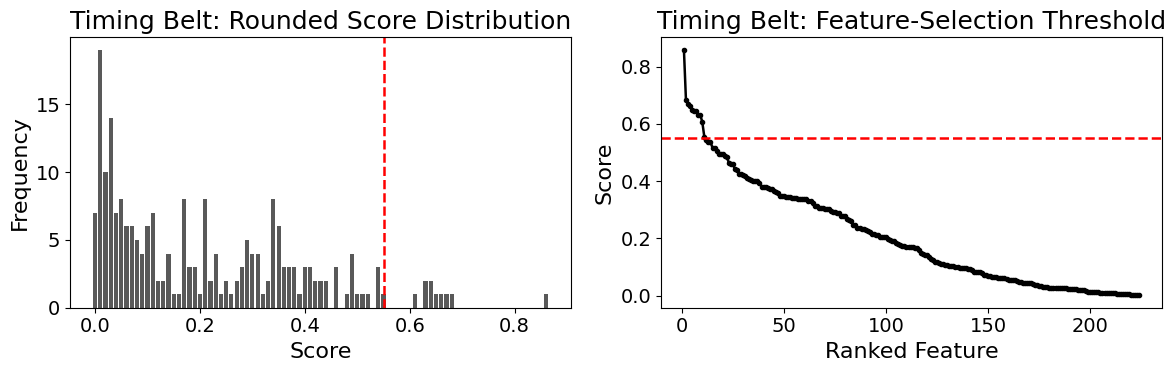

Timing Belt threshold: 0.55  |  selected: 11 features


In [ ]:
def score_threshold(score, order, component_name):
    """Find the score threshold via gap analysis; return (threshold, selected_indices)."""
    sorted_score  = score[order]
    rounded_score = np.round(sorted_score, 2)
    values, counts = np.unique(rounded_score, return_counts=True)
    weighted_diff  = np.diff(values) / counts[1:]
    peaks, _       = find_peaks(weighted_diff)
    if peaks.size >= 4:
        prom_change = np.zeros(peaks.size)
        for idx in range(3, peaks.size):
            prev_mean = np.mean(weighted_diff[peaks[idx-3:idx]])
            if prev_mean > 0:
                prom_change[idx] = 100 * (weighted_diff[peaks[idx]] - prev_mean) / prev_mean
        selected_peak = peaks[np.argmax(prom_change)]
    else:
        selected_peak = int(np.argmax(weighted_diff))
    threshold = values[selected_peak]
    selected  = order[score[order] >= threshold]

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].bar(values, counts, width=0.008, color='0.35')
    axes[0].axvline(threshold, color='red', linestyle='--')
    axes[0].set_xlabel('Score');  axes[0].set_ylabel('Frequency')
    axes[0].set_title(f'{component_name}: Rounded Score Distribution')
    axes[1].plot(np.arange(1, len(sorted_score) + 1), sorted_score, 'k.-')
    axes[1].axhline(threshold, color='red', linestyle='--')
    axes[1].set_xlabel('Ranked Feature');  axes[1].set_ylabel('Score')
    axes[1].set_title(f'{component_name}: Feature-Selection Threshold')
    plt.tight_layout();  plt.show()
    print(f'{component_name} threshold: {threshold:.2f}  |  selected: {len(selected)} features')
    return threshold, selected

hd_threshold, hd_selected = score_threshold(hd_result['score'], hd_result['order'], 'HD')
tb_threshold, tb_selected = score_threshold(tb_result['score'], tb_result['order'], 'Timing Belt')

### Remove redundant features and summarize the selection

In [ ]:
CORRELATION_LIMIT = 0.95

def remove_redundant_features(features, candidates, correlation_limit=0.95):
    """Drop features that are highly correlated with an already-selected one.
    Input : features         - (n_samples, n_features) array
            candidates       - feature indices sorted by descending score
            correlation_limit - |Spearman r| threshold above which a feature is rejected
    Output: (selected_indices_array, rejected_DataFrame)
    """
    features   = np.asarray(features, dtype=float)
    candidates = np.asarray(candidates, dtype=int)
    corr_mat   = pd.DataFrame(features).corr(method='spearman').abs().to_numpy()
    selected, rejected = [], []
    for candidate in candidates:
        if not selected:
            selected.append(candidate);  continue
        sel_corrs  = corr_mat[candidate, selected]
        max_pos    = int(np.nanargmax(sel_corrs))
        max_corr   = sel_corrs[max_pos]
        if max_corr < correlation_limit:
            selected.append(candidate)
        else:
            rejected.append({'Rejected feature':       feature_name_list[candidate],
                             'Retained feature':        feature_name_list[selected[max_pos]],
                             '|Spearman correlation|':  max_corr})
    return np.asarray(selected, dtype=int), pd.DataFrame(rejected)

hd_selected_nonredundant, hd_rejected = remove_redundant_features(
    feat_robot, hd_selected, CORRELATION_LIMIT)
tb_selected_nonredundant, tb_rejected = remove_redundant_features(
    feat_robot, tb_selected, CORRELATION_LIMIT)

def selected_feature_table(result, selected):
    rank_lookup = {feat_idx: rank for rank, feat_idx in enumerate(result['order'], start=1)}
    return pd.DataFrame({
        'Rank':    [rank_lookup[i] for i in selected],
        'Feature': [feature_name_list[i] for i in selected],
        'Score':   result['score'][selected],
    })

hd_final_table = selected_feature_table(hd_result, hd_selected_nonredundant)
tb_final_table = selected_feature_table(tb_result, tb_selected_nonredundant)

print(f'HD: {len(hd_selected)} -> {len(hd_selected_nonredundant)} after redundancy removal')
display(hd_final_table)
print(f'TB: {len(tb_selected)} -> {len(tb_selected_nonredundant)} after redundancy removal')
display(tb_final_table)
print('Rejected HD features');  display(hd_rejected)
print('Rejected TB features');  display(tb_rejected)

HD: 5 -> 1 after redundancy removal


,Rank,Feature,Score
0,1,Cur-W1-STD,1.0


TB: 11 -> 4 after redundancy removal


,Rank,Feature,Score
0,1,Vel-W0-SF,0.859504
1,2,Cur-W7-MF,0.683255
2,3,Cur-W7-Peak(Max),0.669244
3,11,Vel-W7-SF,0.554561


Rejected HD features


,Rejected feature,Retained feature,|Spearman correlation|
0,Cur-W1-RMS,Cur-W1-STD,0.999946
1,Cur-WE1,Cur-W1-STD,0.999946
2,Cur-W1-SE,Cur-W1-STD,0.999809
3,Cur-W1-P2P,Cur-W1-STD,0.961663


Rejected TB features


,Rejected feature,Retained feature,|Spearman correlation|
0,Cur-W7-P2P,Cur-W7-Peak(Max),0.996182
1,Cur-W7-SF,Cur-W7-MF,0.975237
2,Cur-W7-RMS,Cur-W7-Peak(Max),0.983039
3,Cur-W7-STD,Cur-W7-Peak(Max),0.983025
4,Cur-W7-SE,Cur-W7-Peak(Max),0.984999
5,Cur-WE7,Cur-W7-Peak(Max),0.983039
6,Cur-W7-IF,Cur-W7-MF,0.952683


### Visual comparison of the selected features

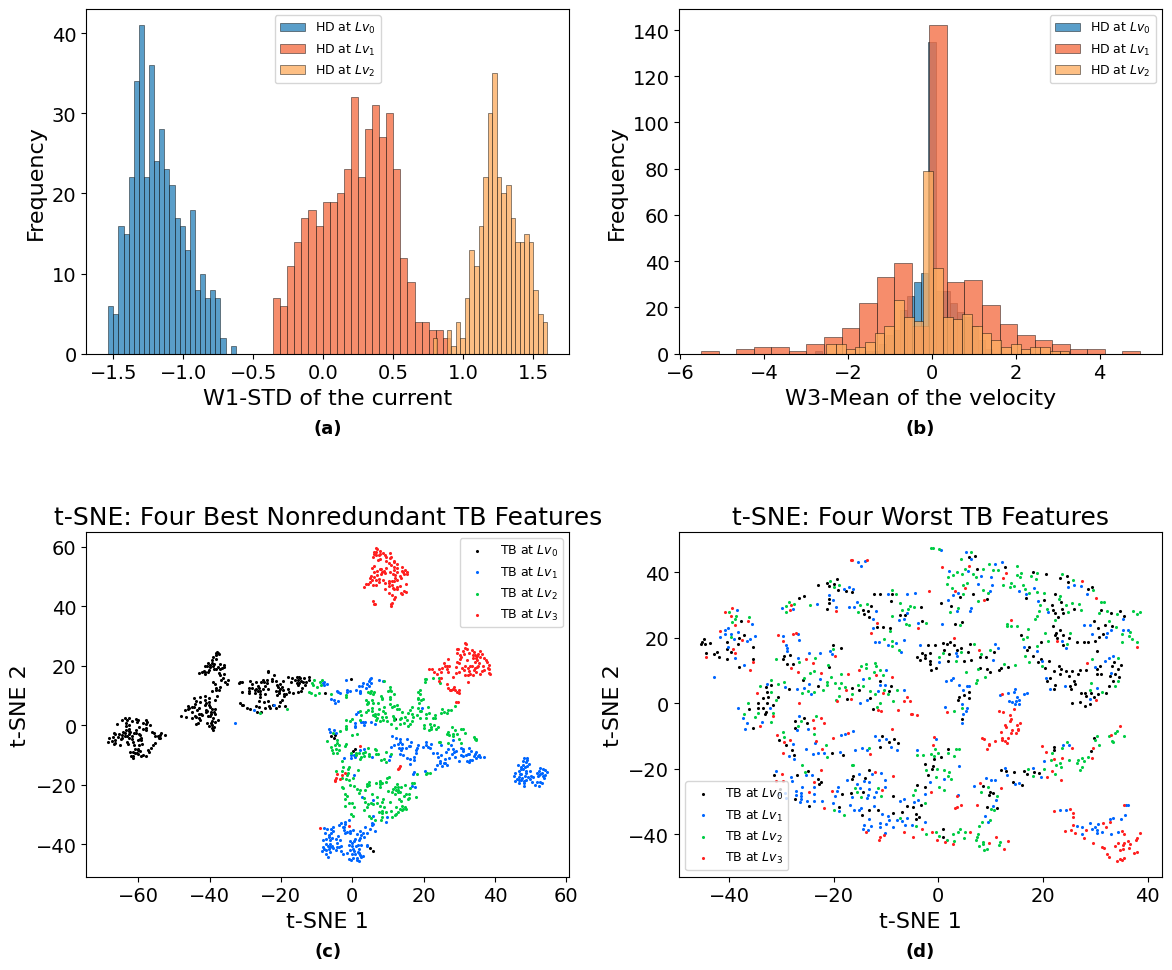

HD best feature: Cur-W1-STD
HD worst feature: Vel-W3-Mean
TB best four: ['Vel-W0-SF', 'Cur-W7-MF', 'Cur-W7-Peak(Max)', 'Vel-W7-SF']


In [ ]:
def feature_axis_label(name):
    """Convert 'Cur-W1-STD' -> 'STD of the current' for axis labels."""
    parts = name.split('-', 1)
    channel = parts[0]
    feature = parts[1] if len(parts) == 2 else name
    signal_name = 'current' if channel == 'Cur' else 'velocity'
    return f'{feature} of the {signal_name}'

def mahalanobis_tsne(features, random_state=0):
    """t-SNE embedding with Mahalanobis pre-distance matrix."""
    features = np.asarray(features, dtype=float)
    inv_cov  = np.linalg.pinv(np.cov(features, rowvar=False))
    dist_mat = squareform(pdist(features, metric='mahalanobis', VI=inv_cov))
    return TSNE(n_components=2, perplexity=30, metric='precomputed',
                method='exact', init='random', learning_rate='auto',
                random_state=random_state).fit_transform(dist_mat)

normalized_features = hd_result['normalized_features']
hd_best  = int(hd_selected_nonredundant[0])
hd_worst = int(hd_result['order'][-1])
tb_best_four  = np.asarray(tb_selected_nonredundant[:4], dtype=int)
tb_worst_four = np.asarray(tb_result['order'][-4:], dtype=int)

if tb_best_four.size < 4:
    raise ValueError('At least four nonredundant TB features are required.')

tb_emb_best  = mahalanobis_tsne(normalized_features[:, tb_best_four],  random_state=0)
tb_emb_worst = mahalanobis_tsne(normalized_features[:, tb_worst_four], random_state=0)

hd_colors = ['#2b83ba', '#f46d43', '#fdae61']
tb_colors = ['black', '#0066ff', '#00cc44', '#ff2020']

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# HD feature histograms: best vs worst
for level, color in zip([0, 1, 2], hd_colors):
    idx = labseg[:, 2] == level
    for ax, feat_idx in zip(axes[0, :], [hd_best, hd_worst]):
        ax.hist(normalized_features[idx, feat_idx], bins=25, color=color,
                edgecolor='black', linewidth=0.4, alpha=0.78,
                label=fr'HD at $Lv_{{{level}}}$')
axes[0, 0].set_xlabel(feature_axis_label(feature_name_list[hd_best]))
axes[0, 1].set_xlabel(feature_axis_label(feature_name_list[hd_worst]))
for ax in axes[0, :]:
    ax.set_ylabel('Frequency');  ax.legend(fontsize=9, frameon=True)

# TB t-SNE: best four vs worst four
for level, color in zip([0, 1, 2, 3], tb_colors):
    idx = labseg[:, 0] == level
    for ax, emb in zip(axes[1, :], [tb_emb_best, tb_emb_worst]):
        ax.scatter(emb[idx, 0], emb[idx, 1], s=6, c=color, marker='.',
                   label=fr'TB at $Lv_{{{level}}}$')

axes[1, 0].set_title('t-SNE: Four Best Nonredundant TB Features')
axes[1, 1].set_title('t-SNE: Four Worst TB Features')
for ax in axes[1, :]:
    ax.set_xlabel('t-SNE 1');  ax.set_ylabel('t-SNE 2')
    ax.legend(fontsize=9, frameon=True)

for ax, panel in zip(axes.ravel(), ['(a)', '(b)', '(c)', '(d)']):
    ax.text(0.5, -0.19, panel, transform=ax.transAxes,
            ha='center', va='top', fontsize=13, fontweight='bold')

plt.tight_layout(h_pad=3.0);  plt.show()
print('HD best feature:', feature_name_list[hd_best])
print('HD worst feature:', feature_name_list[hd_worst])
print('TB best four:', [feature_name_list[i] for i in tb_best_four])

## ANN Training & Application

Estimates HIs of HD and TB. HD Lv0-Lv2 are mapped to HI values {0, 0.5, 1}; TB Lv0-Lv3 to {0, 1/3, 2/3, 1}.

### Prepare ANN inputs and HI targets

In [ ]:
# Paper configuration: one HD feature + four TB features
ann_feature_indices = np.r_[
    np.asarray(hd_selected_nonredundant[:1], dtype=int),
    np.asarray(tb_selected_nonredundant[:4], dtype=int)
]
if ann_feature_indices.size != 5:
    raise ValueError('Exactly one HD and four TB features are required.')
if np.unique(ann_feature_indices).size != ann_feature_indices.size:
    raise ValueError('HD and TB selections contain a duplicate feature.')

ann_feature_names = [feature_name_list[i] for i in ann_feature_indices]
x_ann_raw  = np.asarray(feat_robot[:, ann_feature_indices], dtype=np.float64)
hd_level   = np.asarray(labseg[:, 2], dtype=int)
tb_level   = np.asarray(labseg[:, 0], dtype=int)
hi_targets = np.column_stack([hd_level / 2.0, tb_level / 3.0]).astype(np.float64)

print(f'ANN inputs: {x_ann_raw.shape}  |  HI targets: {hi_targets.shape}')
print('Selected features:', ann_feature_names)

ANN inputs: (1100, 5)  |  HI targets: (1100, 2)
Selected features: ['Cur-W1-STD', 'Vel-W0-SF', 'Cur-W7-MF', 'Cur-W7-Peak(Max)', 'Vel-W7-SF']


### Dataset split

In [ ]:
random_state    = 42
test_ratio      = 0.30
validation_ratio = 0.20

sample_index   = np.arange(len(x_ann_raw))
condition_code = tb_level * 10 + hd_level

development_index, test_index = train_test_split(
    sample_index, test_size=test_ratio,
    stratify=condition_code, random_state=random_state)

ann_train_pos, validation_pos = train_test_split(
    np.arange(len(development_index)), test_size=validation_ratio,
    stratify=condition_code[development_index], random_state=random_state)

ann_train_index  = development_index[ann_train_pos]
validation_index = development_index[validation_pos]

scaler_ann   = StandardScaler()
x_ann_train  = scaler_ann.fit_transform(x_ann_raw[ann_train_index])
x_validation = scaler_ann.transform(x_ann_raw[validation_index])
x_ann_test   = scaler_ann.transform(x_ann_raw[test_index])
y_ann_train  = hi_targets[ann_train_index]
y_validation = hi_targets[validation_index]
y_test       = hi_targets[test_index]

display(pd.DataFrame({
    'Subset':           ['ANN training', 'Validation', 'Independent test'],
    'Samples':          [len(ann_train_index), len(validation_index), len(test_index)],
    'Percent of total': [100*len(ann_train_index)/len(sample_index),
                         100*len(validation_index)/len(sample_index),
                         100*len(test_index)/len(sample_index)]
}).style.format({'Percent of total': '{:.1f}%'}))

,Subset,Samples,Percent of total
0,ANN training,616,56.0%
1,Validation,154,14.0%
2,Independent test,330,30.0%


### Train and validate ANN

The architecture is `5 inputs → 20 tanh neurons → 2 linear outputs`. Trained with Adam and early stopping on validation MSE.

ANN training time: 71.78 s
ANN structure: 5-20-2  |  Best epoch: 500
Train RMSE   — HD: 0.0373, TB: 0.0684
Val RMSE     — HD: 0.0468, TB: 0.0875


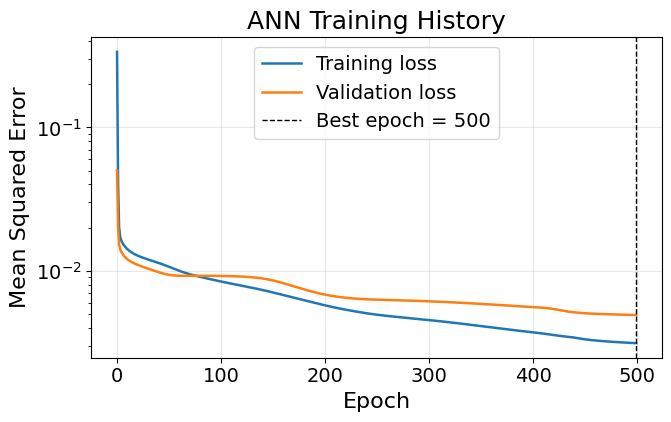

In [ ]:
hidden_neurons  = 20;  learning_rate = 0.005
maximum_epochs  = 500;  batch_size = 32;  patience = 30

tf.keras.utils.set_random_seed(random_state)

ann_model = models.Sequential([
    layers.Input(shape=(x_ann_train.shape[1],)),
    layers.Dense(hidden_neurons, activation='tanh'),
    layers.Dense(2, activation='linear')
])
ann_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
                  loss='mean_squared_error')

start_time = time.time()
history = ann_model.fit(
    x_ann_train, y_ann_train,
    validation_data=(x_validation, y_validation),
    epochs=maximum_epochs, batch_size=batch_size,
    callbacks=[EarlyStopping(monitor='val_loss', patience=patience,
                             restore_best_weights=True)],
    verbose=0
)
print(f'ANN training time: {time.time() - start_time:.2f} s')

best_epoch        = int(np.argmin(history.history['val_loss']) + 1)
train_prediction  = ann_model.predict(x_ann_train, verbose=0)
val_prediction    = ann_model.predict(x_validation, verbose=0)
train_rmse = np.sqrt(np.mean((y_ann_train - train_prediction)**2, axis=0))
val_rmse   = np.sqrt(np.mean((y_validation - val_prediction)**2, axis=0))

print(f'ANN structure: 5-{hidden_neurons}-2  |  Best epoch: {best_epoch}')
print(f'Train RMSE   — HD: {train_rmse[0]:.4f}, TB: {train_rmse[1]:.4f}')
print(f'Val RMSE     — HD: {val_rmse[0]:.4f}, TB: {val_rmse[1]:.4f}')

plt.figure(figsize=(7, 4.5))
plt.plot(history.history['loss'],     label='Training loss')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.axvline(best_epoch - 1, color='black', linestyle='--', linewidth=1,
            label=f'Best epoch = {best_epoch}')
plt.xlabel('Epoch');  plt.ylabel('Mean Squared Error');  plt.title('ANN Training History')
plt.yscale('log');  plt.grid(True, alpha=0.3);  plt.legend()
plt.tight_layout();  plt.show()

### Apply ANN to test set

Independent test samples: 330
HD test RMSE: 0.0513
TB test RMSE: 0.1072


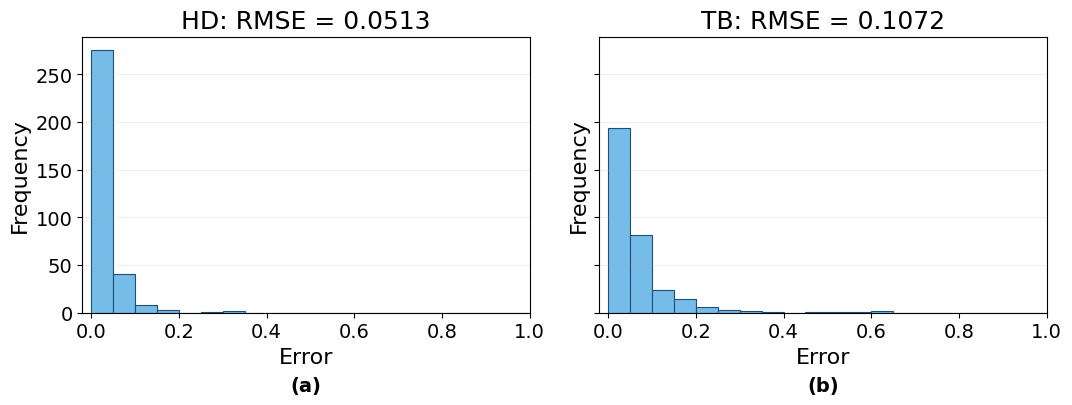

In [ ]:
test_prediction = ann_model.predict(x_ann_test, verbose=0)
test_rmse       = np.sqrt(np.mean((y_test - test_prediction)**2, axis=0))
abs_error       = np.abs(y_test - test_prediction)

print(f'Independent test samples: {len(test_index)}')
print(f'HD test RMSE: {test_rmse[0]:.4f}')
print(f'TB test RMSE: {test_rmse[1]:.4f}')

bins = np.arange(0.0, 1.05, 0.05)
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharey=True)
for idx, (component, panel) in enumerate([('HD', '(a)'), ('TB', '(b)')]):
    axes[idx].hist(abs_error[:, idx], bins=bins,
                   color='#75bce8', edgecolor='#1f4e79', linewidth=0.8)
    axes[idx].set_xlim(-0.02, 1.0);  axes[idx].set_xlabel('Error')
    axes[idx].set_ylabel('Frequency')
    axes[idx].set_title(f'{component}: RMSE = {test_rmse[idx]:.4f}')
    axes[idx].text(0.5, -0.23, panel, transform=axes[idx].transAxes,
                   ha='center', va='top', fontsize=14, fontweight='bold')
    axes[idx].grid(True, axis='y', alpha=0.2)
plt.tight_layout();  plt.show()

### Confusion matrices for severity levels

HD severity accuracy: 0.9909  |  TB severity accuracy: 0.9364


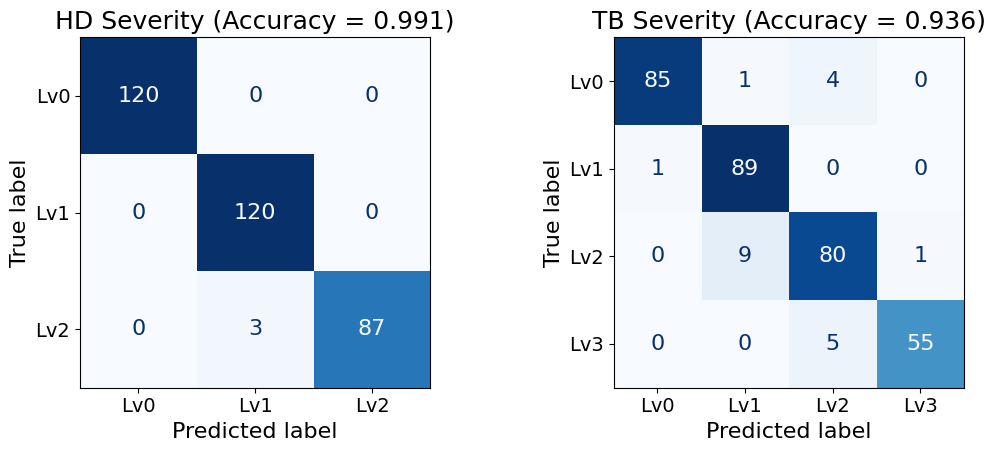

In [ ]:
def nearest_level(predicted_hi, allowed_hi):
    """Map continuous HI predictions to the nearest discrete severity level."""
    return np.argmin(np.abs(np.asarray(predicted_hi)[:, None]
                            - np.asarray(allowed_hi)[None, :]), axis=1)

hd_true_level = hd_level[test_index]
tb_true_level = tb_level[test_index]
hd_pred_level = nearest_level(test_prediction[:, 0], [0.0, 0.5, 1.0])
tb_pred_level = nearest_level(test_prediction[:, 1], [0.0, 1/3, 2/3, 1.0])

hd_accuracy = accuracy_score(hd_true_level, hd_pred_level)
tb_accuracy = accuracy_score(tb_true_level, tb_pred_level)
print(f'HD severity accuracy: {hd_accuracy:.4f}  |  TB severity accuracy: {tb_accuracy:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(11, 4.8))
ConfusionMatrixDisplay(confusion_matrix(hd_true_level, hd_pred_level, labels=[0, 1, 2]),
                       display_labels=['Lv0', 'Lv1', 'Lv2']).plot(
    cmap='Blues', values_format='d', ax=axes[0], colorbar=False)
axes[0].set_title(f'HD Severity (Accuracy = {hd_accuracy:.3f})')
ConfusionMatrixDisplay(confusion_matrix(tb_true_level, tb_pred_level, labels=[0, 1, 2, 3]),
                       display_labels=['Lv0', 'Lv1', 'Lv2', 'Lv3']).plot(
    cmap='Blues', values_format='d', ax=axes[1], colorbar=False)
axes[1].set_title(f'TB Severity (Accuracy = {tb_accuracy:.3f})')
plt.tight_layout();  plt.show()

## Gaussian Process Regression

GPR represents S as a function of TB and HD HIs. Input: $(g_1^n, g_2^n)$ = (TB HI, HD HI); output: vibration RMS normalised to [0, 1].

### Load the GPR dataset

`g1n` is the TB health index, `g2n` is the HD health index, `y` is the vibration RMS. 55 measurements spanning all HD × TB condition combinations.

In [ ]:
gpr_file = ROBOT_ROOT / 'gpr.mat'
if not gpr_file.exists():
    raise FileNotFoundError(f'GPR dataset not found: {gpr_file}')

gpr_data = loadmat(gpr_file, variable_names=['g1n', 'g2n', 'y', 'noisesg'])
tb_hi           = np.asarray(gpr_data['g1n'], dtype=float).reshape(-1)
hd_hi           = np.asarray(gpr_data['g2n'], dtype=float).reshape(-1)
vibration_rms   = np.asarray(gpr_data['y'],   dtype=float).reshape(-1)
gpr_input       = np.column_stack([tb_hi, hd_hi])

rms_min, rms_max = vibration_rms.min(), vibration_rms.max()

def rms_to_system_hi(value):
    """Normalise vibration RMS to system health index in [0, 1]."""
    return (np.asarray(value) - rms_min) / (rms_max - rms_min)

print(f'GPR input: {gpr_input.shape}  |  Vibration RMS: {vibration_rms.shape}')
print(f'RMS range: {rms_min:.4f} to {rms_max:.4f}')

GPR input: (55, 2)  |  Vibration RMS: (55,)
RMS range: 0.1046 to 0.2104


### Construct the GPR model

A squared-exponential covariance function is used, plus a constant basis and white-noise kernel. Initial hyperparameters taken from the paper; optimised via maximum likelihood.

In [ ]:
initial_length_scale = 0.9525;  initial_signal_std = 0.0467;  initial_noise_std = 0.0130

# MATLAB fitrgp uses a constant mean; train zero-mean GP on residuals
gpr_constant_mean  = vibration_rms.mean()
vibration_residual = vibration_rms - gpr_constant_mean

gpr_kernel = (
    ConstantKernel(constant_value=initial_signal_std**2,
                   constant_value_bounds=(1e-4, 1.0))
    * RBF(length_scale=initial_length_scale, length_scale_bounds=(0.05, 10.0))
    + WhiteKernel(noise_level=initial_noise_std**2, noise_level_bounds=(1e-6, 0.1))
)

gpr_model = GaussianProcessRegressor(kernel=gpr_kernel, normalize_y=False,
                                      n_restarts_optimizer=10, random_state=42)
gpr_model.fit(gpr_input, vibration_residual)

print('Optimized kernel:');  print(gpr_model.kernel_)
print(f'Log marginal likelihood: {gpr_model.log_marginal_likelihood_value_:.4f}')

Optimized kernel:
0.0449**2 * RBF(length_scale=0.876) + WhiteKernel(noise_level=9.36e-05)
Log marginal likelihood: 164.0255


### GPR response surface and component responses

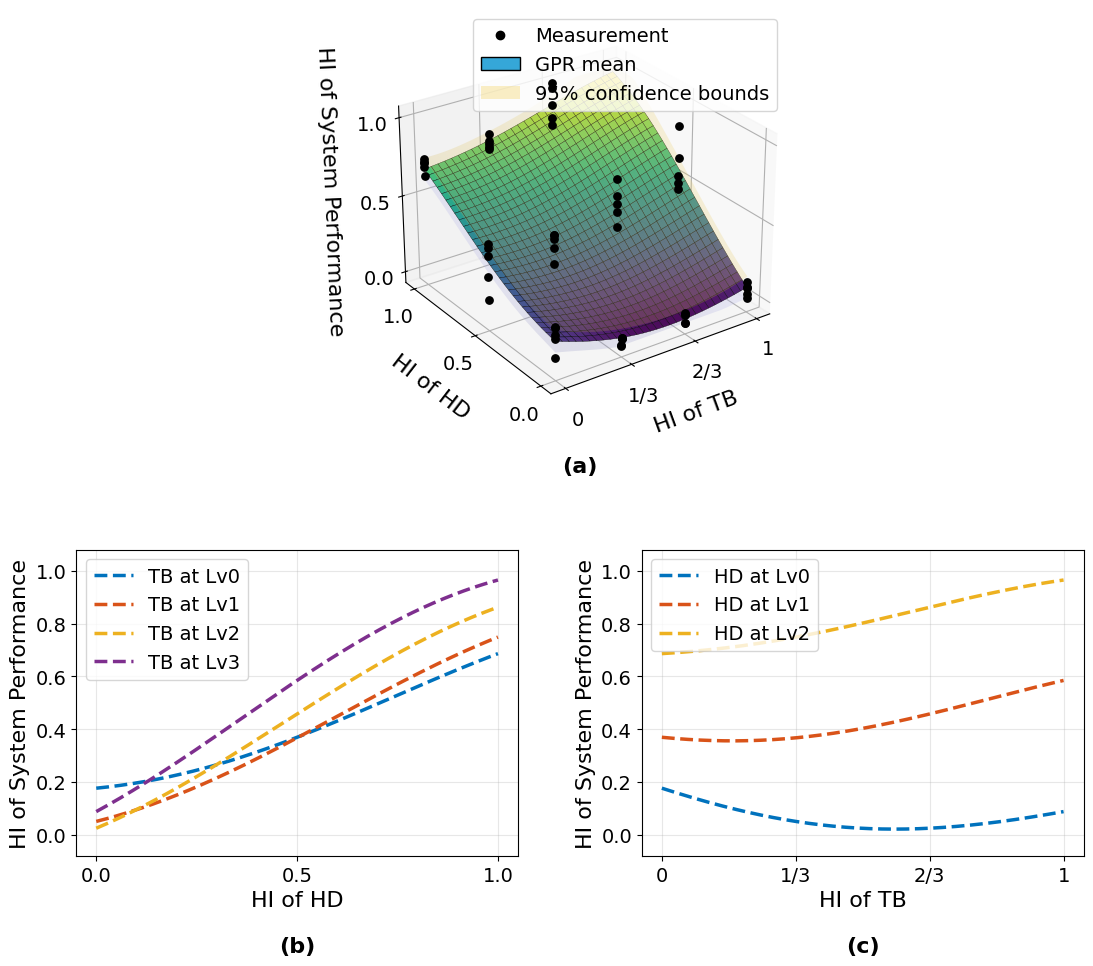

In [ ]:
grid_size = 30
tb_axis = np.linspace(0.0, 1.0, grid_size)
hd_axis = np.linspace(0.0, 1.0, grid_size)
tb_grid, hd_grid = np.meshgrid(tb_axis, hd_axis)
grid_input = np.column_stack([tb_grid.ravel(), hd_grid.ravel()])

grid_rms_res, grid_pred_std = gpr_model.predict(grid_input, return_std=True)
grid_rms_mean = gpr_constant_mean + grid_rms_res

noise_var       = gpr_model.kernel_.k2.noise_level
grid_latent_std = np.sqrt(np.maximum(grid_pred_std**2 - noise_var, 0.0))

system_hi_mean  = rms_to_system_hi(grid_rms_mean).reshape(tb_grid.shape)
system_hi_std   = (grid_latent_std / (rms_max - rms_min)).reshape(tb_grid.shape)
system_hi_lower = np.clip(system_hi_mean - 1.96 * system_hi_std, 0.0, 1.0)
system_hi_upper = np.clip(system_hi_mean + 1.96 * system_hi_std, 0.0, 1.0)
measured_sys_hi = rms_to_system_hi(vibration_rms)

figure = plt.figure(figsize=(13, 11))
layout  = figure.add_gridspec(2, 2, height_ratios=[1.35, 1.0], hspace=0.35, wspace=0.28)

# (a) 3-D response surface
ax_s = figure.add_subplot(layout[0, :], projection='3d')
ax_s.scatter(tb_hi, hd_hi, measured_sys_hi, color='black', s=28, depthshade=False, zorder=5)
ax_s.plot_surface(tb_grid, hd_grid, system_hi_mean, cmap='viridis',
                  edgecolor='black', linewidth=0.25, alpha=0.95)
ax_s.plot_surface(tb_grid, hd_grid, system_hi_upper, color='#f4d35e', edgecolor='none', alpha=0.22)
ax_s.plot_surface(tb_grid, hd_grid, system_hi_lower, color='#b8b8ff', edgecolor='none', alpha=0.22)
ax_s.set_xlabel('HI of TB', labelpad=10);  ax_s.set_ylabel('HI of HD', labelpad=10)
ax_s.set_zlabel('HI of System Performance', labelpad=10)
ax_s.set_xticks([0, 1/3, 2/3, 1]);  ax_s.set_xticklabels(['0', '1/3', '2/3', '1'])
ax_s.set_yticks([0, 0.5, 1]);  ax_s.set_zticks([0, 0.5, 1])
ax_s.view_init(elev=27, azim=-125)
ax_s.legend(handles=[
    Line2D([0], [0], marker='o', color='none', markerfacecolor='black',
           markersize=6, label='Measurement'),
    Patch(facecolor='#35a7d8', edgecolor='black', label='GPR mean'),
    Patch(facecolor='#f4d35e', alpha=0.35, label='95% confidence bounds')
], loc='upper right')
ax_s.text2D(0.5, -0.08, '(a)', transform=ax_s.transAxes,
            ha='center', va='top', fontweight='bold')

# (b) HD slice response
ax_hd = figure.add_subplot(layout[1, 0])
hd_line = np.linspace(0.0, 1.0, 200)
for level, color, label in zip([0.0, 1/3, 2/3, 1.0],
                                 ['#0072BD', '#D95319', '#EDB120', '#7E2F8E'],
                                 ['TB at Lv0', 'TB at Lv1', 'TB at Lv2', 'TB at Lv3']):
    resp = gpr_constant_mean + gpr_model.predict(
        np.column_stack([np.full_like(hd_line, level), hd_line]))
    ax_hd.plot(hd_line, rms_to_system_hi(resp), '--', color=color, lw=2.5, label=label)
ax_hd.set_xlabel('HI of HD');  ax_hd.set_ylabel('HI of System Performance')
ax_hd.set_xticks([0, 0.5, 1]);  ax_hd.set_ylim(-0.08, 1.08)
ax_hd.grid(True, alpha=0.3);  ax_hd.legend(loc='upper left')
ax_hd.text(0.5, -0.26, '(b)', transform=ax_hd.transAxes,
           ha='center', va='top', fontweight='bold')

# (c) TB slice response
ax_tb = figure.add_subplot(layout[1, 1])
tb_line = np.linspace(0.0, 1.0, 200)
for level, color, label in zip([0.0, 0.5, 1.0],
                                 ['#0072BD', '#D95319', '#EDB120'],
                                 ['HD at Lv0', 'HD at Lv1', 'HD at Lv2']):
    resp = gpr_constant_mean + gpr_model.predict(
        np.column_stack([tb_line, np.full_like(tb_line, level)]))
    ax_tb.plot(tb_line, rms_to_system_hi(resp), '--', color=color, lw=2.5, label=label)
ax_tb.set_xlabel('HI of TB');  ax_tb.set_ylabel('HI of System Performance')
ax_tb.set_xticks([0, 1/3, 2/3, 1]);  ax_tb.set_xticklabels(['0', '1/3', '2/3', '1'])
ax_tb.set_ylim(-0.08, 1.08);  ax_tb.grid(True, alpha=0.3);  ax_tb.legend(loc='upper left')
ax_tb.text(0.5, -0.26, '(c)', transform=ax_tb.transAxes,
           ha='center', va='top', fontweight='bold')
plt.show()

## What-if Study and Maintenance Scenario

### Evaluate the current and restored states

For a consistent comparison, every scenario uses the same GPR model from Section 4.

In [ ]:
def predict_system_hi(tb_value, hd_value):
    """GPR prediction with 95% CI for a single (TB, HD) point."""
    res_mean, res_std = gpr_model.predict(np.array([[tb_value, hd_value]]), return_std=True)
    res_std  = np.sqrt(np.maximum(res_std**2 - gpr_model.kernel_.k2.noise_level, 0))
    hi_mean  = float(rms_to_system_hi(gpr_constant_mean + res_mean[0]))
    hi_std   = float(res_std[0] / (rms_max - rms_min))
    return hi_mean, max(0.0, hi_mean - 1.96*hi_std), min(1.0, hi_mean + 1.96*hi_std)

current_hd_level, current_tb_level = 1, 2
current_hd_hi    = current_hd_level / 2
current_tb_hi    = current_tb_level / 3
condition_name   = f'HD Lv{current_hd_level}–TB Lv{current_tb_level}'

current_sys_hi, cur_lo, cur_hi   = predict_system_hi(current_tb_hi, current_hd_hi)
sys_after_hd,   hd_lo,  hd_hi   = predict_system_hi(current_tb_hi, 0.0)
sys_after_tb,   tb_lo,  tb_hi   = predict_system_hi(0.0,           current_hd_hi)

scenario_table = pd.DataFrame({
    'State':     [f'Current: {condition_name}', 'Restore HD only', 'Restore TB only'],
    'HD HI':     [current_hd_hi, 0.0,           current_hd_hi],
    'TB HI':     [current_tb_hi, current_tb_hi, 0.0],
    'GPR mean S':[current_sys_hi, sys_after_hd,  sys_after_tb],
    'Lower 95%': [cur_lo,         hd_lo,          tb_lo],
    'Upper 95%': [cur_hi,         hd_hi,          tb_hi],
})
display(scenario_table.round(3))
print(f'Recommended action: {"Restore HD" if sys_after_hd < sys_after_tb else "Restore TB"}')

,State,HD HI,TB HI,GPR mean S,Lower 95%,Upper 95%
0,Current: HD Lv1–TB Lv2,0.5,0.667,0.458,0.404,0.512
1,Restore HD only,0.0,0.667,0.026,0.000,0.083
2,Restore TB only,0.5,0.000,0.370,0.304,0.436


Recommended action: Restore HD


### Current health and maintenance effects

The three panels compare the current health state with the two single-component restoration scenarios.

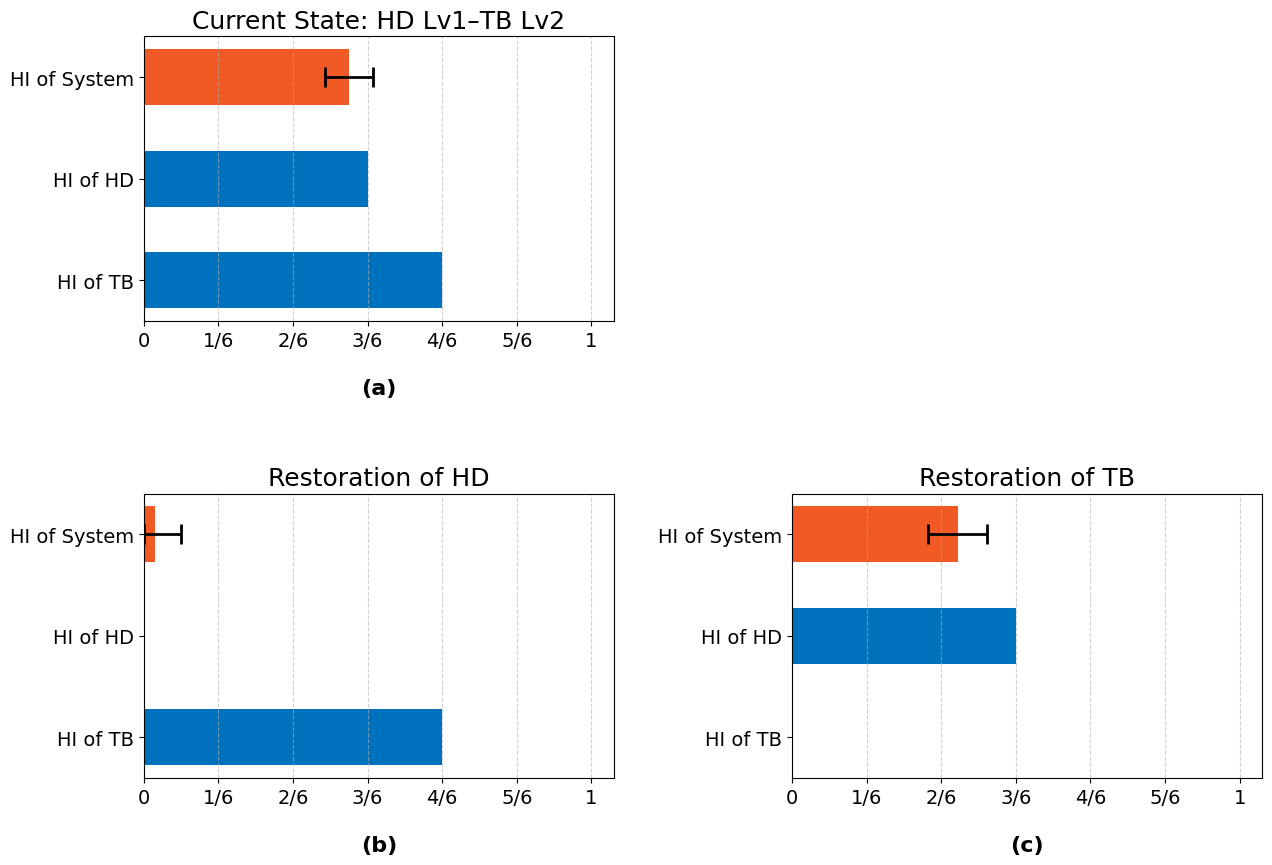

In [ ]:
def fraction_tick(value, position):
    """Tick formatter that renders common fractions (0, 1/6, ..., 1)."""
    labels = {0:'0', 1/6:'1/6', 2/6:'2/6', 3/6:'3/6', 4/6:'4/6', 5/6:'5/6', 1:'1'}
    nearest = min(labels, key=lambda t: abs(t - value))
    return labels[nearest] if abs(nearest - value) < 1e-6 else ''

def plot_health_state(axis, title, hd_value, tb_value, system_value, lower, upper):
    """Horizontal bar chart with a system-HI error bar for one maintenance scenario."""
    values = [system_value, hd_value, tb_value]
    axis.barh(np.arange(3), values, color=['#F15A24', '#0072BD', '#0072BD'], height=0.55)
    xerr = np.array([[system_value - lower], [upper - system_value]])
    axis.errorbar(system_value, 0, xerr=xerr, fmt='none',
                  ecolor='black', elinewidth=2, capsize=7, capthick=2)
    axis.set_yticks(np.arange(3), ['HI of System', 'HI of HD', 'HI of TB'])
    axis.invert_yaxis();  axis.set_xlim(0, 1.05)
    axis.set_xticks(np.arange(0, 1.01, 1/6))
    axis.xaxis.set_major_formatter(FuncFormatter(fraction_tick))
    axis.grid(True, axis='x', linestyle='--', alpha=0.6)
    axis.set_title(title)

figure, axes = plt.subplots(2, 2, figsize=(13, 9))
plot_health_state(axes[0, 0], f'Current State: {condition_name}',
                  current_hd_hi, current_tb_hi, current_sys_hi, cur_lo, cur_hi)
plot_health_state(axes[1, 0], 'Restoration of HD',
                  0.0, current_tb_hi, sys_after_hd, hd_lo, hd_hi)
plot_health_state(axes[1, 1], 'Restoration of TB',
                  current_hd_hi, 0.0, sys_after_tb, tb_lo, tb_hi)
axes[0, 1].axis('off')
for axis, label in zip([axes[0, 0], axes[1, 0], axes[1, 1]], ['(a)', '(b)', '(c)']):
    axis.text(0.5, -0.20, label, transform=axis.transAxes,
              ha='center', va='top', fontweight='bold')
plt.tight_layout(h_pad=2.8, w_pad=2.0);  plt.show()

# Bayesian Network for Robot

- **BN 1**: HD, TB → features. Structure learning reduces 224 candidate features to 5 via BIC. CPDs are Gaussian.
- **BN 2**: HD, TB → S (system HI). Uses a Bayesian quadratic regression on the 55 GPR measurements.

## Load Features_robot.mat and gpr.mat, and split data.

In [ ]:
feature_file = ROBOT_ROOT / 'Features_robot.mat'
gpr_file     = ROBOT_ROOT / 'gpr.mat'

feature_data  = loadmat(feature_file)
feat_robot    = np.asarray(feature_data['feat_robot'], dtype=float)
labseg        = np.asarray(feature_data['labseg'],     dtype=int)
feature_names = matlab_strings(feature_data['feat_name'])

tb_level    = labseg[:, 0].astype(int)
hd_level    = labseg[:, 2].astype(int)
joint_level = 10 * hd_level + tb_level

if feat_robot.shape != (1100, 224) or labseg.shape[0] != 1100:
    raise ValueError(f'Unexpected data shapes: {feat_robot.shape}, {labseg.shape}')

print('Features:', feat_robot.shape, ' | HD levels:', np.unique(hd_level),
      ' | TB levels:', np.unique(tb_level))

TEST_SIZE    = 0.30
RANDOM_STATE = 42

train_idx, test_idx = train_test_split(
    np.arange(len(feat_robot)), test_size=TEST_SIZE,
    random_state=RANDOM_STATE, stratify=joint_level)
print(f'Training: {len(train_idx)}  |  Test: {len(test_idx)}')
assert len(train_idx) == 770 and len(test_idx) == 330

Features: (1100, 224)  | HD levels: [0 1 2]  | TB levels: [0 1 2 3]
Training: 770  |  Test: 330


## Feature selection by structure learning

For each feature, BIC determines whether its best parent set is None / HD only / TB only / HD+TB. Features with Delta BIC > threshold and low mutual correlation are selected.

In [ ]:
DELTA_BIC_MIN = 10
CORR_LIMIT    = 0.8
MAX_FEATURES  = 5

x_train  = feat_robot[train_idx]
hd_train = hd_level[train_idx]
tb_train = tb_level[train_idx]

def gaussian_bic(x, groups):
    """BIC for a Gaussian mixture with one mean/std per group."""
    log_likelihood = sum(
        np.sum(norm.logpdf(x[groups == g],
                           loc=np.mean(x[groups == g]),
                           scale=max(np.std(x[groups == g]), 1e-10)))
        for g in np.unique(groups))
    n_params = 2 * len(np.unique(groups))
    return -2 * log_likelihood + n_params * np.log(len(x))

parent_models = {
    'None':  np.zeros(len(train_idx), dtype=int),
    'HD':    hd_train,
    'TB':    tb_train,
    'HD+TB': 10 * hd_train + tb_train,
}

# BIC-based structure learning for all 224 features
results = []
for j in range(feat_robot.shape[1]):
    bic = {name: gaussian_bic(x_train[:, j], groups)
           for name, groups in parent_models.items()}
    best_parent = min(bic, key=bic.get)
    results.append([j, feature_names[j], best_parent, bic['None'] - bic[best_parent]])

structure_table = pd.DataFrame(results, columns=['Index', 'Feature', 'Parent set', 'Delta BIC']
                               ).sort_values('Delta BIC', ascending=False)

# Select strongly related and nonredundant features
selected_indices = []
for _, row in structure_table.iterrows():
    j = int(row['Index'])
    if row['Delta BIC'] <= DELTA_BIC_MIN: continue
    redundant = any(
        np.isfinite(spearmanr(x_train[:, j], x_train[:, k]).statistic)
        and abs(spearmanr(x_train[:, j], x_train[:, k]).statistic) >= CORR_LIMIT
        for k in selected_indices)
    if not redundant: selected_indices.append(j)
    if len(selected_indices) >= MAX_FEATURES: break

selected_structure = structure_table.set_index('Index').loc[selected_indices].reset_index()
print(f'Features with Delta BIC > {DELTA_BIC_MIN}: '
      f'{(structure_table["Delta BIC"] > DELTA_BIC_MIN).sum()}')
print(f'Final selected: {len(selected_indices)}')
display(selected_structure)

Features with Delta BIC > 10: 221
Final selected: 5


,Index,Feature,Parent set,Delta BIC
0,109,Cur-W7-SE,HD+TB,5058.675616
1,95,Cur-W6-SE,HD+TB,4691.205037
2,67,Cur-W4-SE,HD+TB,3065.267688
3,4,Cur-W0-KUR,HD+TB,2966.740493
4,25,Cur-W1-SE,HD+TB,2921.609447


### Option: use paper-defined features

The five features from the paper can be used directly instead of running the automatic selection above.

In [ ]:
# Five features selected in the paper (uncomment to override automatic selection)
# selected_features = ['Cur-W1-STD', 'Cur-W7-MF', 'Cur-W7-Peak(Max)',
#                      'Vel-W0-SF', 'Vel-W7-SF']
# selected_indices = [list(feature_names).index(name) for name in selected_features]
# selected_structure = pd.DataFrame({
#     'Index': selected_indices, 'Feature': selected_features,
#     'Parent set': ['HD+TB'] * len(selected_features)
# })
# display(selected_structure)

## BN for HD and TB Diagnosis

Posterior $P(HD,TB\mid F)$ is calculated for each test sample via the learnt CPDs.

In [ ]:
selected_parent_sets = selected_structure['Parent set'].tolist()
train_mean = feat_robot[train_idx][:, selected_indices].mean(axis=0)
train_std  = feat_robot[train_idx][:, selected_indices].std(axis=0, ddof=0)
train_std[train_std < 1e-12] = 1.0

x_train = (feat_robot[train_idx][:, selected_indices] - train_mean) / train_std
x_test  = (feat_robot[test_idx][:, selected_indices]  - train_mean) / train_std

valid_states  = sorted(set(zip(hd_train.tolist(), tb_train.tolist())))
state_to_id   = {state: i for i, state in enumerate(valid_states)}
state_train   = np.array([state_to_id[(h, t)] for h, t in zip(hd_train, tb_train)])
state_counts  = np.bincount(state_train, minlength=len(valid_states))
state_prior   = (state_counts + 1.0) / (len(state_train) + len(valid_states))

def parent_key(parent_set, hd, tb):
    """Map (parent_set, hd, tb) to a scalar group key."""
    if parent_set == 'HD':    return int(hd)
    if parent_set == 'TB':    return int(tb)
    if parent_set == 'HD+TB': return int(10 * hd + tb)
    return 0

# Estimate Gaussian CPD parameters for each selected feature
feature_cpds = []
for col, parent_set in enumerate(selected_parent_sets):
    groups     = np.array([parent_key(parent_set, h, t)
                            for h, t in zip(hd_train, tb_train)])
    parameters = {}
    for group in np.unique(groups):
        values = x_train[groups == group, col]
        parameters[int(group)] = (float(values.mean()),
                                   max(float(values.std(ddof=0)), 0.05))
    feature_cpds.append((parent_set, parameters))

def joint_posterior(feature_matrix):
    """Compute P(state | features) for each row of feature_matrix.
    Output: (n_samples, n_states) probability array.
    """
    log_prob = np.tile(np.log(state_prior), (len(feature_matrix), 1))
    for state_id, (hd, tb) in enumerate(valid_states):
        for col, (parent_set, parameters) in enumerate(feature_cpds):
            mean, std = parameters[parent_key(parent_set, hd, tb)]
            log_prob[:, state_id] += norm.logpdf(feature_matrix[:, col], mean, std)
    log_prob -= logsumexp(log_prob, axis=1, keepdims=True)
    return np.exp(log_prob)

### Example diagnosis for a sample feature

One feature sample from HD HI = 0.5, TB HI = 2/3 in the test set.

,Component,True HI,Posterior mean,Lower 95%,Upper 95%,Predicted level,Correct
0,HD,0.500,0.500,0.500,0.500,0.500,True
1,TB,0.667,0.625,0.333,0.667,0.667,True


/tmp/ipykernel_619/422673179.py:63: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout();  plt.show()


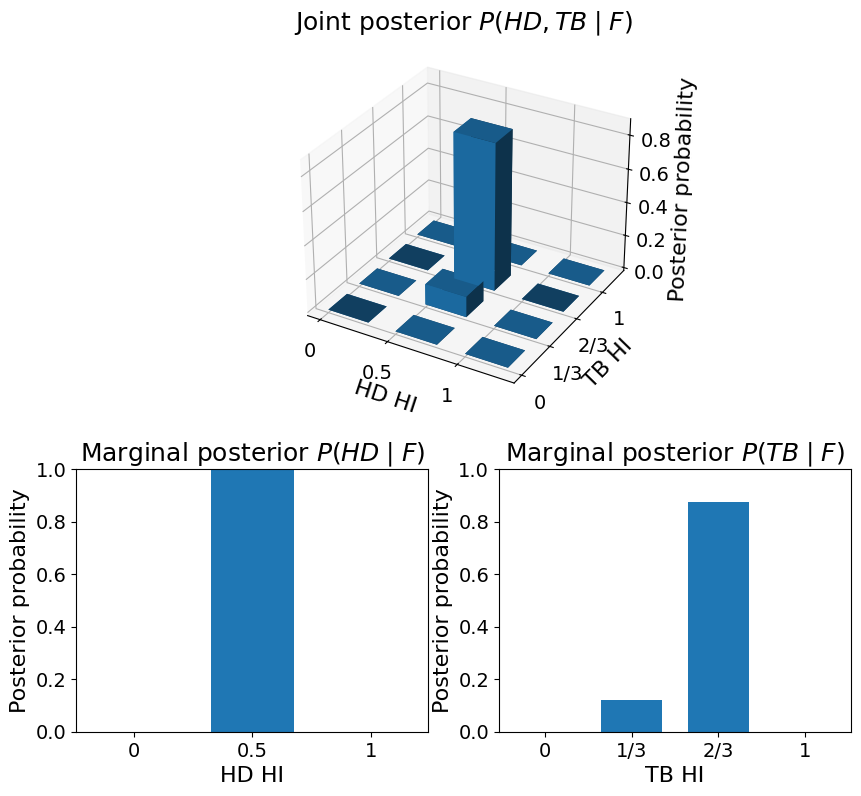

In [ ]:
example_hd_hi = 0.5;  example_tb_hi = 2/3
candidates = test_idx[(hd_level[test_idx] / 2 == example_hd_hi) &
                      (tb_level[test_idx] / 3 == example_tb_hi)]
example_id  = candidates[0]

x_example = (feat_robot[[example_id]][:, selected_indices] - train_mean) / train_std
posterior  = joint_posterior(x_example)[0]
levels     = {'HD': np.array([0, 0.5, 1]), 'TB': np.array([0, 1/3, 2/3, 1])}

rows = []
posterior_probs = {}
for k, (name, values) in enumerate(levels.items()):
    prob = np.array([
        posterior[[i for i, state in enumerate(valid_states) if state[k] == j]].sum()
        for j in range(len(values))
    ])
    posterior_probs[name] = prob
    mean      = prob @ values
    cdf       = np.cumsum(prob)
    predicted = values[np.argmin(np.abs(values - mean))]
    true      = example_hd_hi if name == 'HD' else example_tb_hi
    rows.append([name, true, mean,
                 values[np.searchsorted(cdf, 0.025)],
                 values[np.searchsorted(cdf, 0.975)],
                 predicted, np.isclose(predicted, true)])

display(pd.DataFrame(rows, columns=[
    'Component', 'True HI', 'Posterior mean',
    'Lower 95%', 'Upper 95%', 'Predicted level', 'Correct'
]).round(3))

p_joint = np.zeros((3, 4))
for prob, (hd, tb) in zip(posterior, valid_states):
    p_joint[hd, tb] = prob
p_hd_example = p_joint.sum(axis=1)
p_tb_example = p_joint.sum(axis=0)

fig = plt.figure(figsize=(10, 9))
grid = fig.add_gridspec(2, 2, height_ratios=[1.4, 1])

ax_joint = fig.add_subplot(grid[0, :], projection='3d')
hd_g, tb_g = np.meshgrid(range(3), range(4), indexing='ij')
ax_joint.bar3d(hd_g.ravel(), tb_g.ravel(), np.zeros(12),
               0.6, 0.6, p_joint.ravel(), shade=True)
ax_joint.set_xticks(range(3), ['0', '0.5', '1'])
ax_joint.set_yticks(range(4), ['0', '1/3', '2/3', '1'])
ax_joint.set_xlabel('HD HI');  ax_joint.set_ylabel('TB HI')
ax_joint.set_zlabel('Posterior probability')
ax_joint.set_title(r'Joint posterior $P(HD,TB\mid F)$')

ax_hd = fig.add_subplot(grid[1, 0])
ax_hd.bar(range(3), p_hd_example, width=0.7)
ax_hd.set_xticks(range(3), ['0', '0.5', '1'])
ax_hd.set_xlabel('HD HI');  ax_hd.set_ylabel('Posterior probability')
ax_hd.set_ylim(0, 1);  ax_hd.set_title(r'Marginal posterior $P(HD\mid F)$')

ax_tb = fig.add_subplot(grid[1, 1])
ax_tb.bar(range(4), p_tb_example, width=0.7)
ax_tb.set_xticks(range(4), ['0', '1/3', '2/3', '1'])
ax_tb.set_xlabel('TB HI');  ax_tb.set_ylabel('Posterior probability')
ax_tb.set_ylim(0, 1);  ax_tb.set_title(r'Marginal posterior $P(TB\mid F)$')

plt.tight_layout();  plt.show()

### Application to full test set

,Component,Accuracy,Log loss,Test samples
0,HD,1.000000,2.147867e-07,330
1,TB,0.948485,1.640480e-01,330


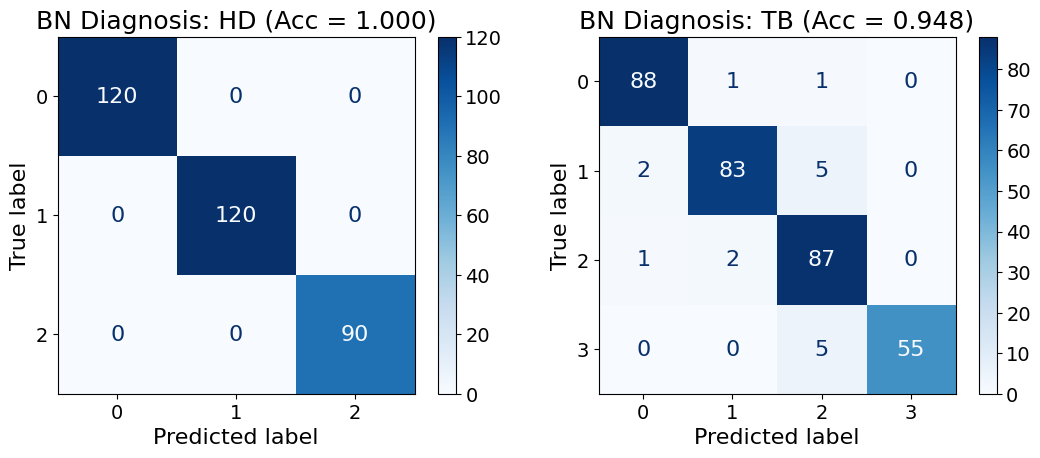

In [ ]:
posterior_test = joint_posterior(x_test)

p_hd = np.column_stack([
    posterior_test[:, [i for i, state in enumerate(valid_states) if state[0] == lv]].sum(axis=1)
    for lv in range(3)])
p_tb = np.column_stack([
    posterior_test[:, [i for i, state in enumerate(valid_states) if state[1] == lv]].sum(axis=1)
    for lv in range(4)])

pred_hd, pred_tb = p_hd.argmax(axis=1), p_tb.argmax(axis=1)

metrics_bn1 = pd.DataFrame({
    'Component':   ['HD', 'TB'],
    'Accuracy':    [accuracy_score(hd_level[test_idx], pred_hd),
                    accuracy_score(tb_level[test_idx], pred_tb)],
    'Log loss':    [log_loss(hd_level[test_idx], p_hd),
                    log_loss(tb_level[test_idx], p_tb)],
    'Test samples':[len(test_idx), len(test_idx)],
})
display(metrics_bn1)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
ConfusionMatrixDisplay.from_predictions(hd_level[test_idx], pred_hd, ax=axes[0], cmap='Blues')
ConfusionMatrixDisplay.from_predictions(tb_level[test_idx], pred_tb, ax=axes[1], cmap='Blues')
axes[0].set_title(f'BN Diagnosis: HD (Acc = {metrics_bn1.Accuracy.iloc[0]:.3f})')
axes[1].set_title(f'BN Diagnosis: TB (Acc = {metrics_bn1.Accuracy.iloc[1]:.3f})')
plt.tight_layout();  plt.show()

## BN for S from HD and TB

The 55 measured vibration RMS values are converted to system HI and fitted by a Bayesian quadratic regression with unknown noise variance.

In [ ]:
gpr_data    = loadmat(gpr_file, variable_names=['g1n', 'g2n', 'y'])
tb_gpr      = np.asarray(gpr_data['g1n'], dtype=float).reshape(-1)
hd_gpr      = np.asarray(gpr_data['g2n'], dtype=float).reshape(-1)
rms_gpr     = np.asarray(gpr_data['y'],   dtype=float).reshape(-1)
s_gpr       = (rms_gpr - rms_gpr.min()) / (rms_gpr.max() - rms_gpr.min())

def system_basis(hd, tb):
    """Quadratic basis [1, hd, tb, hd*tb, hd^2, tb^2] for system BN."""
    hd, tb = np.asarray(hd), np.asarray(tb)
    return np.column_stack([np.ones(np.size(hd)), hd.ravel(), tb.ravel(),
                             (hd*tb).ravel(), (hd**2).ravel(), (tb**2).ravel()])

# Bayesian linear regression with Normal-InverseGamma prior
design  = system_basis(hd_gpr, tb_gpr);  p = design.shape[1]
beta0   = np.zeros(p);  prior_cov = np.eye(p) * 100.0
prior_prec = np.linalg.inv(prior_cov)
post_cov   = np.linalg.inv(prior_prec + design.T @ design)
post_beta  = post_cov @ (prior_prec @ beta0 + design.T @ s_gpr)
a0, b0     = 2.0, 0.1
a_post     = a0 + len(s_gpr) / 2.0
b_post     = b0 + 0.5 * (s_gpr @ s_gpr - post_beta @ np.linalg.solve(post_cov, post_beta))

print('BN 2 training measurements:', len(s_gpr))
print('System-HI range:', s_gpr.min(), 'to', s_gpr.max())

BN 2 training measurements: 55
System-HI range: 0.0 to 1.0


## Probabilistic Maintenance Scenarios

The joint posterior from the example diagnosis propagates through BN 2 to obtain a predictive distribution over S for three scenarios.

,Variable,Mean,Lower 95%,Upper 95%
0,System HI,0.421,0.341,0.481
1,HD HI,0.500,0.500,0.500
2,TB HI,0.626,0.333,0.667


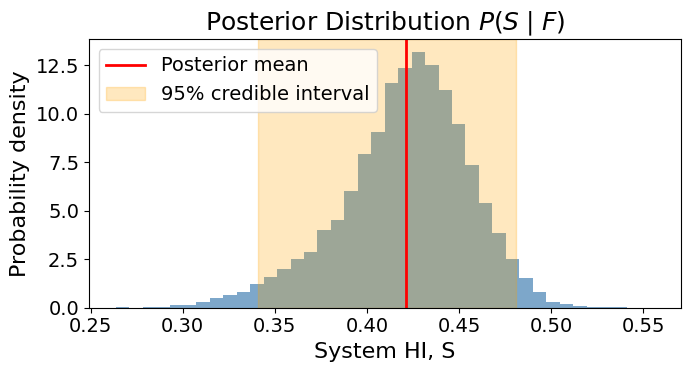

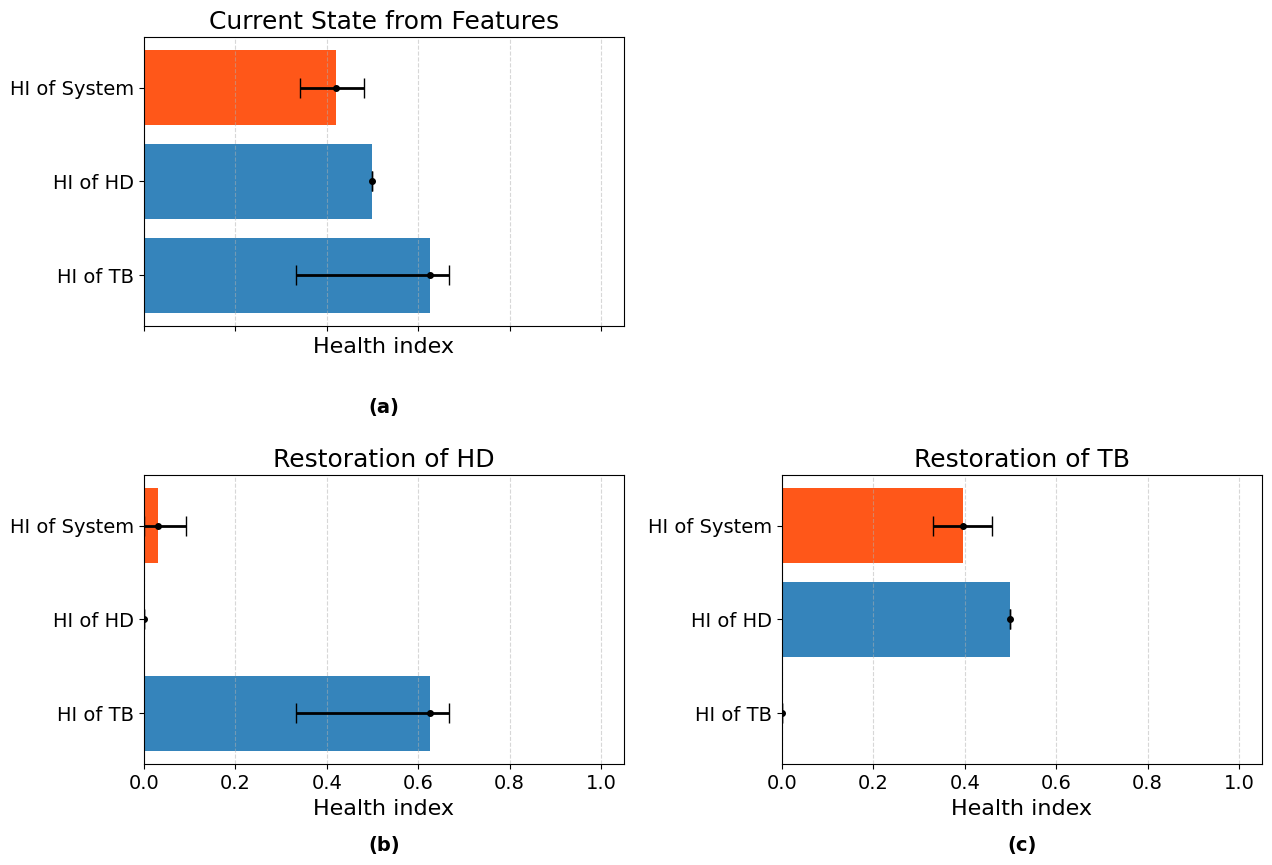

In [ ]:
N_POSTERIOR_DRAWS = 20000
rng_bn = np.random.default_rng(RANDOM_STATE)

# Draw (HD, TB) jointly from BN 1 posterior of the previous example diagnosis
state_draws         = np.array(valid_states)[rng_bn.choice(len(valid_states),
                       N_POSTERIOR_DRAWS, p=posterior)]
hd_draws, tb_draws  = state_draws[:, 0] / 2, state_draws[:, 1] / 3

# Draw BN 2 response surface coefficients and noise variance
sigma2_draws = invgamma.rvs(a=a_post, scale=b_post,
                             size=N_POSTERIOR_DRAWS, random_state=rng_bn)
beta_draws   = np.array([rng_bn.multivariate_normal(post_beta, s2 * post_cov)
                          for s2 in sigma2_draws])

scenarios = {
    'Current State from Features': (hd_draws,                    tb_draws),
    'Restoration of HD':           (np.zeros(N_POSTERIOR_DRAWS), tb_draws),
    'Restoration of TB':           (hd_draws, np.zeros(N_POSTERIOR_DRAWS)),
}

results = {}
for name, (hd, tb) in scenarios.items():
    draws = np.clip(np.sum(beta_draws * system_basis(hd, tb), axis=1), 0, 1)
    results[name] = {
        'hd': hd.mean(), 'hd_lower': np.quantile(hd, 0.025), 'hd_upper': np.quantile(hd, 0.975),
        'tb': tb.mean(), 'tb_lower': np.quantile(tb, 0.025), 'tb_upper': np.quantile(tb, 0.975),
        'mean': draws.mean(), 'lower': np.quantile(draws, 0.025),
        'upper': np.quantile(draws, 0.975), 'draws': draws
    }

current = results['Current State from Features']
display(pd.DataFrame({
    'Variable': ['System HI', 'HD HI', 'TB HI'],
    'Mean':      [current['mean'],  hd_draws.mean(), tb_draws.mean()],
    'Lower 95%': [current['lower'], np.quantile(hd_draws, 0.025), np.quantile(tb_draws, 0.025)],
    'Upper 95%': [current['upper'], np.quantile(hd_draws, 0.975), np.quantile(tb_draws, 0.975)],
}).round(3))

plt.figure(figsize=(7, 4))
plt.hist(current['draws'], bins=40, density=True, color='steelblue', alpha=0.7)
plt.axvline(current['mean'],  color='red',    linewidth=2, label='Posterior mean')
plt.axvspan(current['lower'], current['upper'], color='orange', alpha=0.25,
            label='95% credible interval')
plt.xlabel('System HI, S');  plt.ylabel('Probability density')
plt.title(r'Posterior Distribution $P(S\mid F)$');  plt.legend()
plt.tight_layout();  plt.show()

fig, axes = plt.subplots(2, 2, figsize=(13, 9), sharex=True)
plot_axes = [axes[0, 0], axes[1, 0], axes[1, 1]]
for ax, label, (title, result) in zip(plot_axes, ['(a)', '(b)', '(c)'], results.items()):
    values = np.array([result['tb'],    result['hd'],    result['mean']])
    lower  = np.array([result['tb_lower'], result['hd_lower'], result['lower']])
    upper  = np.array([result['tb_upper'], result['hd_upper'], result['upper']])
    ax.barh(['HI of TB', 'HI of HD', 'HI of System'], values,
            color=['tab:blue', 'tab:blue', 'orangered'], alpha=0.9)
    ax.errorbar(values, range(3), xerr=[values - lower, upper - values],
                fmt='o', color='black', markersize=4, capsize=7, linewidth=2)
    ax.set_title(title);  ax.set_xlabel('Health index')
    ax.set_xlim(0, 1.05);  ax.set_xticks(np.arange(0, 1.01, 0.2))
    ax.grid(axis='x', linestyle='--', alpha=0.5)
    ax.text(0.5, -0.25, label, transform=ax.transAxes,
            ha='center', va='top', fontsize=14, fontweight='bold')
axes[0, 1].axis('off')
plt.tight_layout();  plt.show()

# Kalman Filter

## Constant Voltage Estimation

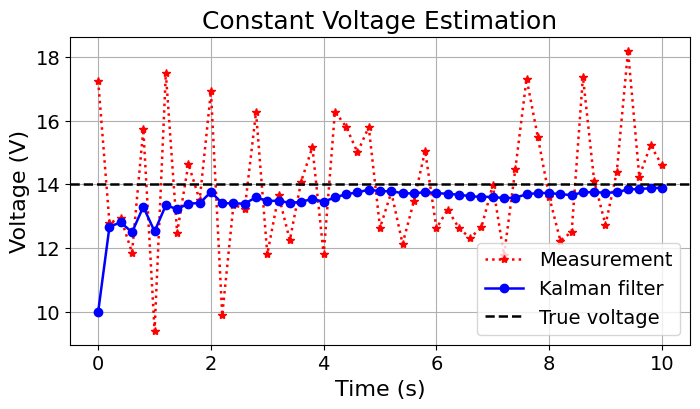

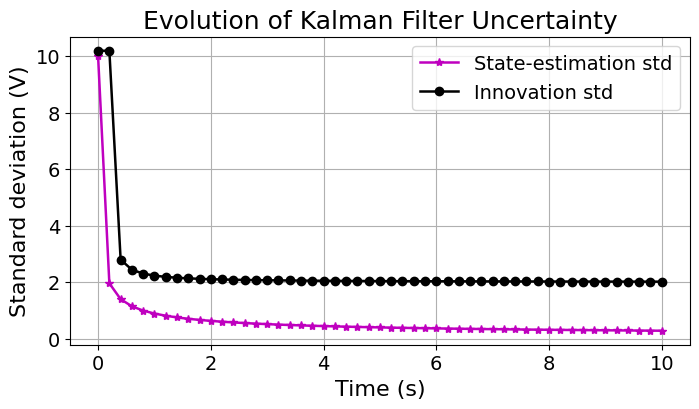

Final estimate = 13.893 V


In [ ]:
np.random.seed(1)

t            = np.arange(0, 10.2, 0.2)
true_voltage = 14;  s_kf = 2
z            = true_voltage + s_kf * np.random.randn(len(t))
Q_kf         = 0;  R_kf = s_kf**2

xhat = np.zeros(len(t));  P_kf = np.zeros(len(t));  S_kf = np.zeros(len(t))
xhat[0] = 10;  P_kf[0] = 100;  S_kf[0] = P_kf[0] + R_kf

for k in range(1, len(t)):
    P0      = P_kf[k-1] + Q_kf;  S_kf[k] = P0 + R_kf;  K = P0 / S_kf[k]
    xhat[k] = xhat[k-1] + K * (z[k] - xhat[k-1]);  P_kf[k] = (1 - K) * P0

plt.figure(figsize=(8, 4))
plt.plot(t, z,    'r:*', label='Measurement')
plt.plot(t, xhat, 'bo-', label='Kalman filter')
plt.axhline(true_voltage, color='k', ls='--', label='True voltage')
plt.xlabel('Time (s)');  plt.ylabel('Voltage (V)')
plt.title('Constant Voltage Estimation');  plt.legend();  plt.grid()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(t, np.sqrt(P_kf),  'm*-', label='State-estimation std')
plt.plot(t, np.sqrt(S_kf),  'ko-', label='Innovation std')
plt.xlabel('Time (s)');  plt.ylabel('Standard deviation (V)')
plt.title('Evolution of Kalman Filter Uncertainty');  plt.legend();  plt.grid()
plt.show()
print(f'Final estimate = {xhat[-1]:.3f} V')

## Linear Varying Voltage

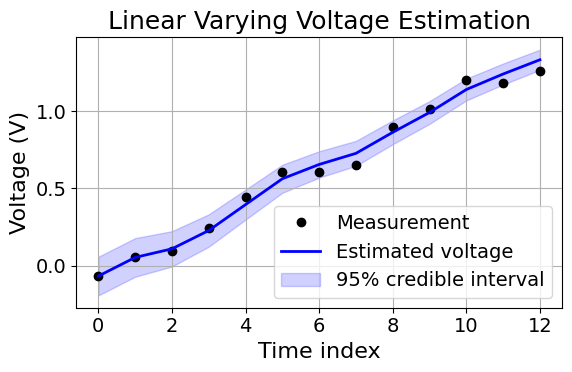

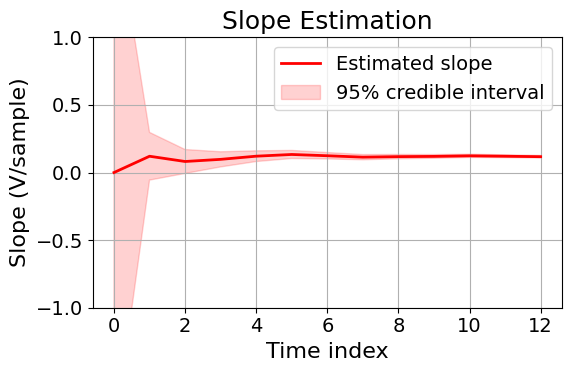

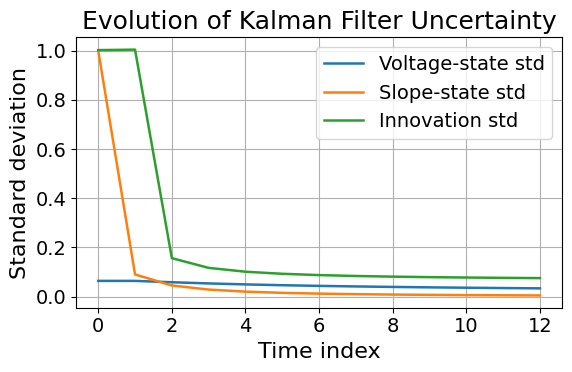

Final voltage estimate = 1.3332 V
Final slope estimate   = 0.1171 V/sample


In [ ]:
z  = np.array([-0.0679, 0.0538, 0.0959, 0.2435, 0.4423, 0.6050, 0.6080,
                0.6542, 0.9005, 1.0126, 1.2034, 1.1855, 1.2586])
t  = np.arange(len(z));  n = len(z)

# KF model: state X = [voltage x, slope b]
F = np.array([[1, 1.0], [0, 1]])   # dt = 1
H = np.array([[1, 0]])
Q = np.zeros((2, 2));  R = 0.064**2
X = np.array([0.0, 0.0]);  P = np.eye(2)

Xhat = np.zeros((n, 2));  Phat = np.zeros((n, 2, 2));  S_kf = np.zeros(n);  I2 = np.eye(2)

for k in range(n):
    if k > 0:
        X = F @ X;  P = F @ P @ F.T + Q
    S_kf[k] = (H @ P @ H.T)[0, 0] + R
    K        = P @ H.T / S_kf[k]
    X        = X + K[:, 0] * (z[k] - (H @ X)[0])
    P        = (I2 - K @ H) @ P
    Xhat[k]  = X;  Phat[k] = P

std_x = np.sqrt(Phat[:, 0, 0]);  std_b = np.sqrt(Phat[:, 1, 1]);  ci = 1.96

plt.figure(figsize=(6, 4))
plt.plot(t, z, 'ko', label='Measurement')
plt.plot(t, Xhat[:, 0], 'b-', lw=2, label='Estimated voltage')
plt.fill_between(t, Xhat[:, 0]-ci*std_x, Xhat[:, 0]+ci*std_x,
                 color='b', alpha=0.18, label='95% credible interval')
plt.xlabel('Time index');  plt.ylabel('Voltage (V)')
plt.title('Linear Varying Voltage Estimation');  plt.grid();  plt.legend()
plt.tight_layout();  plt.show()

plt.figure(figsize=(6, 4))
plt.plot(t, Xhat[:, 1], 'r-', lw=2, label='Estimated slope')
plt.fill_between(t, Xhat[:, 1]-ci*std_b, Xhat[:, 1]+ci*std_b,
                 color='r', alpha=0.18, label='95% credible interval')
plt.xlabel('Time index');  plt.ylabel('Slope (V/sample)');  plt.ylim(-1, 1)
plt.title('Slope Estimation');  plt.grid();  plt.legend()
plt.tight_layout();  plt.show()

plt.figure(figsize=(6, 4))
plt.plot(t, std_x, label='Voltage-state std')
plt.plot(t, std_b, label='Slope-state std')
plt.plot(t, np.sqrt(S_kf), label='Innovation std')
plt.xlabel('Time index');  plt.ylabel('Standard deviation')
plt.title('Evolution of Kalman Filter Uncertainty');  plt.grid();  plt.legend()
plt.tight_layout();  plt.show()

print(f'Final voltage estimate = {Xhat[-1, 0]:.4f} V')
print(f'Final slope estimate   = {Xhat[-1, 1]:.4f} V/sample')

# Optional: save animation to Drive
make_animation = False
gif_path = PROJECT_ROOT / 'kalman_linear_voltage.gif'

if make_animation:
    fig, ax_anim = plt.subplots(1, 2, figsize=(12, 4.5))
    def update(frame):
        k = frame + 1
        for a in ax_anim: a.clear()
        ax_anim[0].plot(t[:k], z[:k], 'ko', label='Measurement')
        ax_anim[0].plot(t[:k], Xhat[:k, 0], 'b-', lw=2, label='Estimated voltage')
        ax_anim[0].fill_between(t[:k], Xhat[:k, 0]-ci*std_x[:k], Xhat[:k, 0]+ci*std_x[:k],
                                color='b', alpha=0.18, label='95% credible interval')
        ax_anim[0].set(xlim=(t[0], t[-1]), ylim=(-0.3, 1.6),
                       xlabel='Time index', ylabel='Voltage',
                       title='Linear Varying Voltage Estimation')
        ax_anim[0].grid();  ax_anim[0].legend(loc='upper left')
        ax_anim[1].plot(t[:k], Xhat[:k, 1], 'r-', lw=2, label='Estimated slope')
        ax_anim[1].fill_between(t[:k], Xhat[:k, 1]-ci*std_b[:k], Xhat[:k, 1]+ci*std_b[:k],
                                color='r', alpha=0.18, label='95% credible interval')
        ax_anim[1].set(xlim=(t[0], t[-1]), ylim=(-0.5, 0.5),
                       xlabel='Time index', ylabel='Slope (V/sample)', title='Slope Estimation')
        ax_anim[1].grid();  ax_anim[1].legend(loc='upper right')
        fig.tight_layout()
    FuncAnimation(fig, update, frames=n, interval=700).save(
        gif_path, writer=PillowWriter(fps=1.5))
    plt.close(fig);  print(f'Animation saved to: {gif_path}')

## Motor Fault Simulation for EKF

### Simulation Data for EKF

Simple first-order motor model: $J\dot{x} + cx = u$, where $x$ is speed, $c$ is the damping coefficient (fault parameter).

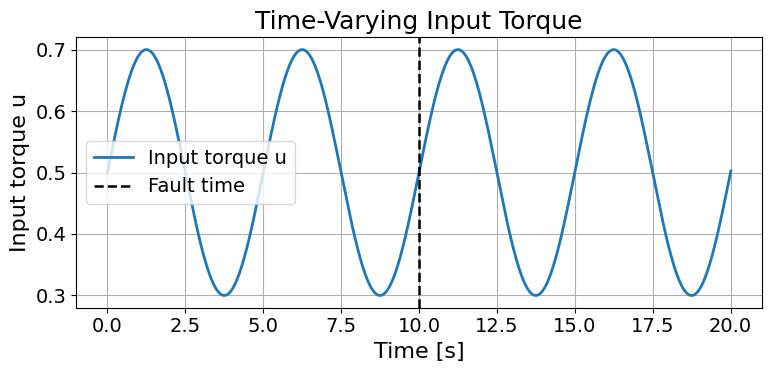

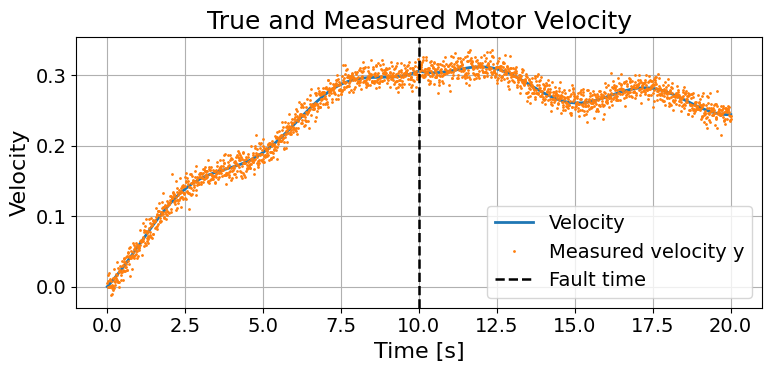

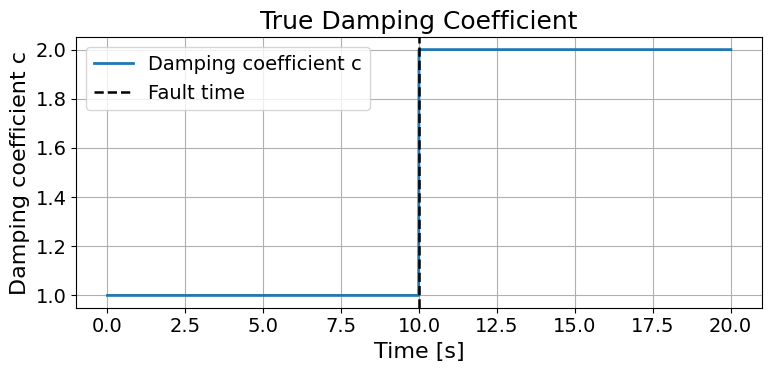

In [ ]:
# First-order motor model: J dx/dt + c x = u
# State to estimate: [x, c]; c steps from 1.0 to 2.0 at t = fault_time
dt_ekf    = 0.01;  J_ekf = 10;  fault_time = 10
t_ekf     = np.arange(0, 20 + dt_ekf, dt_ekf)
u_ekf     = 0.5 + 0.2 * np.sin(2 * np.pi * 0.2 * t_ekf)
c_true    = np.where(t_ekf < fault_time, 1.0, 2.0)

x_true = np.zeros(len(t_ekf))
for k in range(len(t_ekf) - 1):
    x_true[k+1] = x_true[k] + dt_ekf * (u_ekf[k] - c_true[k] * x_true[k]) / J_ekf

np.random.seed(42)
s_meas  = 0.01
y_meas  = x_true + s_meas * np.random.randn(len(t_ekf))

for data, ylabel, title in [
    (u_ekf,  'Input torque u',         'Time-Varying Input Torque'),
    (x_true, 'Velocity',               'True and Measured Motor Velocity'),
    (c_true, 'Damping coefficient c',  'True Damping Coefficient'),
]:
    plt.figure(figsize=(8, 4))
    plt.plot(t_ekf, data, lw=2, label=ylabel)
    if ylabel == 'Velocity':
        plt.plot(t_ekf, y_meas, '.', ms=2, label='Measured velocity y')
    plt.axvline(fault_time, color='k', ls='--', label='Fault time')
    plt.xlabel('Time [s]');  plt.ylabel(ylabel);  plt.title(title)
    plt.grid();  plt.legend();  plt.tight_layout();  plt.show()

### Diagnosis Using EKF

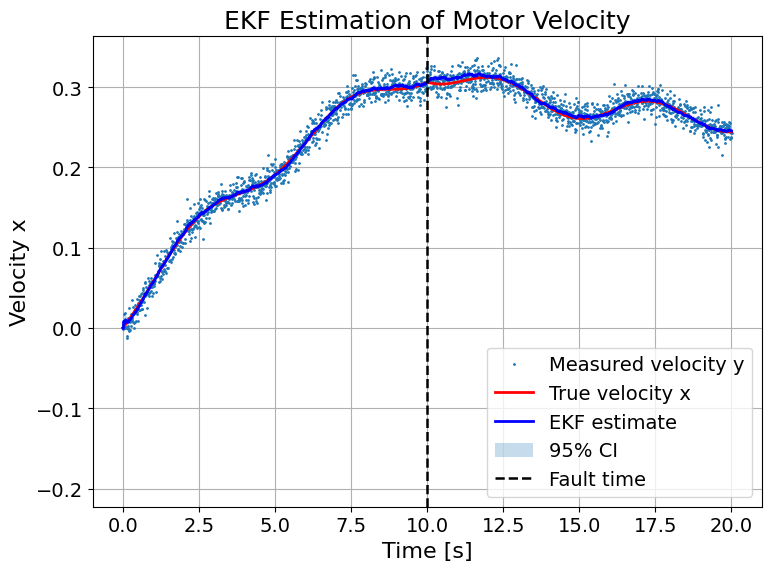

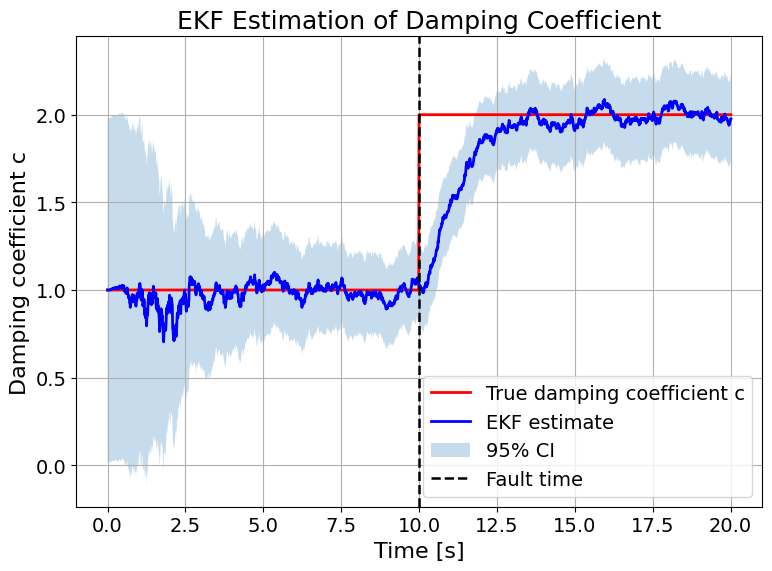

In [ ]:
# EKF state: X = [velocity x, damping coefficient c]
n_ekf  = len(t_ekf)
Xhat_ekf = np.zeros((2, n_ekf));  P_ekf = np.zeros((2, 2, n_ekf))
Xhat_ekf[:, 0] = [0, 1];  P_ekf[:, :, 0] = np.diag([0.1**2, 0.5**2])
Q_ekf = np.diag([1e-7, 1e-4]);  R_ekf = s_meas**2
H_ekf = np.array([[1., 0.]]);   I2_ekf = np.eye(2)

for k in range(1, n_ekf):
    x_val, c_val = Xhat_ekf[:, k-1]
    X0  = np.array([x_val + dt_ekf * (u_ekf[k-1] - c_val * x_val) / J_ekf, c_val])
    F   = np.array([[1 - dt_ekf*c_val/J_ekf, -dt_ekf*x_val/J_ekf], [0, 1]])
    P0  = F @ P_ekf[:, :, k-1] @ F.T + Q_ekf
    S_k = (H_ekf @ P0 @ H_ekf.T)[0, 0] + R_ekf
    K   = P0 @ H_ekf.T / S_k
    Xhat_ekf[:, k]   = X0 + K[:, 0] * (y_meas[k] - X0[0])
    P_ekf[:, :, k]   = (I2_ekf - K @ H_ekf) @ P0

std_ekf = np.sqrt(np.stack([P_ekf[0, 0], P_ekf[1, 1]]))

def plot_ekf_result(j, true_vals, ylabel, title, show_meas=False):
    plt.figure(figsize=(8, 6))
    if show_meas: plt.plot(t_ekf, y_meas, '.', ms=2, label='Measured velocity y')
    plt.plot(t_ekf, true_vals,   'r-', lw=2, label=f'True {ylabel.lower()}')
    plt.plot(t_ekf, Xhat_ekf[j], 'b-', lw=2, label='EKF estimate')
    plt.fill_between(t_ekf, Xhat_ekf[j] - 1.96*std_ekf[j],
                            Xhat_ekf[j] + 1.96*std_ekf[j], alpha=0.25, label='95% CI')
    plt.axvline(fault_time, color='k', ls='--', label='Fault time')
    plt.xlabel('Time [s]');  plt.ylabel(ylabel);  plt.title(title)
    plt.grid();  plt.legend();  plt.tight_layout();  plt.show()

plot_ekf_result(0, x_true, 'Velocity x', 'EKF Estimation of Motor Velocity', show_meas=True)
plot_ekf_result(1, c_true, 'Damping coefficient c', 'EKF Estimation of Damping Coefficient')

# PMDC Load-Torque Estimation by EKF

Identify the fixed motor parameters and estimate time-varying load torque $T_L$ using an extended Kalman filter applied to real PMDC motor data.

In [ ]:
data_file = DATA_ROOT / 'Motor_PMDC' / 'PMDC_MotorA.mat'
data      = loadmat(data_file, simplify_cells=True)

In [ ]:
# Data selection (test IDs start from 1)
# Fixed-parameter identification: 3 PWM levels x 5 loads x 8 tests = 120 tests
cal_pwms     = [80, 90, 100]
cal_loads    = [0, 1, 2, 3, 4]
cal_test_ids = list(range(1, 9))

# EKF load-torque estimation at 50% PWM
test_pwm   = 50
test_loads = [0, 1, 2, 3, 4]
test_ids   = [7, 7, 7, 7, 9]

true_torque = np.array([0, 0.059820565, 0.119641130, 0.179461695, 0.239282260])


## 1. Fixed-Parameter Identification

In [ ]:
from scipy.optimize import lsq_linear

def get_tests(pwm, load):
    """Return test arrays for a given PWM and load."""
    value = data[f'pwm{pwm}_load{load}']
    return list(value) if value.dtype == object or value.ndim == 3 else [value]

def regression_data(pwms, loads, test_ids=None, excluded_ids=None):
    """Build regression data for the fixed parameters J, b, and k_T."""
    x_all, y_all, n_tests = [], [], 0
    excluded_ids = set(excluded_ids or [])

    for pwm in pwms:
        for load in loads:
            tests = get_tests(pwm, load)
            ids = test_ids or range(1, len(tests) + 1)

            for test_id in ids:
                if test_id > len(tests) or test_id in excluded_ids:
                    continue

                test = tests[test_id - 1]
                torque = true_torque[load]
                start = np.flatnonzero(test[:, 2] > 5)[0]
                test = test[start:]

                dt_m = np.median(np.diff(test[:, 0]))
                speed = savgol_filter(test[:, 2], 11, 3)
                accel = savgol_filter(test[:, 2], 11, 3, deriv=1, delta=dt_m)

                # J*accel + b*speed - k_T*current = -T_L
                x_all.append(np.column_stack([accel, speed, -test[:, 1]]))
                y_all.append(np.full(len(test), -torque))
                n_tests += 1

    return np.vstack(x_all), np.concatenate(y_all), n_tests

x_cal, y_cal, n_cal = regression_data(cal_pwms, cal_loads, cal_test_ids)

# Scale columns before nonnegative constrained least squares.
scale = np.linalg.norm(x_cal, axis=0)
if np.any(scale == 0):
    raise ValueError('A regression column has zero norm.')
x_scaled = x_cal / scale
result = lsq_linear(x_scaled, y_cal, bounds=(0, np.inf))
if not result.success:
    raise RuntimeError(result.message)

J_pm, b_pm, k_T_pm = result.x / scale

print(f'Identification tests = {n_cal}')
print(f'J   = {J_pm:.6e} kg m^2')
print(f'b   = {b_pm:.6e} N m s/rad')
print(f'k_T = {k_T_pm:.6e} N m/A')
print(f'Condition number = {np.linalg.cond(x_scaled):.3e}')


Identification tests = 120
J   = 1.438163e-04 kg m^2
b   = 3.369819e-04 N m s/rad
k_T = 3.935539e-02 N m/A
Condition number = 2.633e+00


In [ ]:
parameters = np.array([J_pm, b_pm, k_T_pm])

# Overall identification and validation performance
for name, ids, excluded in [
    ('Identification', cal_test_ids, None),
    ('Validation', None, cal_test_ids)
]:
    x, y, n = regression_data(cal_pwms, cal_loads, ids, excluded)
    residual = x @ parameters - y
    rmse = np.sqrt(np.mean(residual**2))
    r2 = 1 - np.sum(residual**2) / np.sum((y - y.mean())**2)
    print(f'{name:14s}: tests = {n:3d}, RMSE = {rmse:.5f} N m, R² = {r2:.3f}')

# Validation performance by load level
validation_rows = []
for load in cal_loads:
    x, y, n = regression_data(
        cal_pwms, [load], test_ids=None, excluded_ids=cal_test_ids
    )
    residual = x @ parameters - y
    validation_rows.append({
        'Load [kgf]': load,
        'Reference T_L [N m]': true_torque[load],
        'Validation tests': n,
        'RMSE [N m]': np.sqrt(np.mean(residual**2)),
    })

display(pd.DataFrame(validation_rows))


Identification: tests = 120, RMSE = 0.03483 N m, R² = 0.845
Validation    : tests =  33, RMSE = 0.03469 N m, R² = 0.836


,Load [kgf],Reference T_L [N m],Validation tests,RMSE [N m]
0,0,0.000000,6,0.023470
1,1,0.059821,7,0.020151
2,2,0.119641,8,0.029735
3,3,0.179462,6,0.040385
4,4,0.239282,6,0.050310


## 2. EKF Load-Torque Estimation

In [ ]:
P0_pm    = np.diag([1.0, 0.5**2])
Q_pm     = np.zeros((2, 2))
R_pm     = 0.01
substeps = 5

def ekf_pmdc(test):
    """Estimate speed and constant load torque using the fixed-J motor model."""
    start = np.flatnonzero(test[:, 2] > 5)[0]
    time, current, measured_speed = test[start:, :3].T
    state = np.array([measured_speed[0], 0.0])
    covariance = P0_pm.copy()
    history = np.empty((len(time), 2))
    history[0] = state
    H_pm = np.array([[1.0, 0.0]])

    for index, dt_step in enumerate(np.diff(time)):
        step = dt_step / substeps
        for _ in range(substeps):
            speed, torque = state
            numerator = k_T_pm * current[index] - b_pm * speed - torque
            state += step * np.array([numerator / J_pm, 0.0])
            F_pm = np.array([[-b_pm/J_pm, -1/J_pm], [0.0, 0.0]])
            A_pm = np.eye(2) + step * F_pm
            covariance = A_pm @ covariance @ A_pm.T + Q_pm * step

        innovation = measured_speed[index + 1] - H_pm @ state
        S_pm = float(H_pm @ covariance @ H_pm.T + R_pm)
        K_pm = covariance @ H_pm.T / S_pm
        state += K_pm[:, 0] * float(innovation)
        I_KH = np.eye(2) - K_pm @ H_pm
        covariance = I_KH @ covariance @ I_KH.T + K_pm * R_pm @ K_pm.T
        history[index + 1] = state

    return time - time[0], history

results_pmdc = [
    ekf_pmdc(get_tests(test_pwm, load)[test_id - 1])
    for load, test_id in zip(test_loads, test_ids)
]
estimates = np.array([history[-1, 1] for _, history in results_pmdc])

print('Load  Test ID  True T_L  EKF T_L  Error (%)')
for load, test_id, estimate in zip(test_loads, test_ids, estimates):
    truth = true_torque[load]
    error = np.nan if truth == 0 else 100 * (estimate - truth) / truth
    print(f'{load:4d}{test_id:9d}{truth:10.3f}{estimate:9.3f}{error:11.1f}')


/tmp/ipykernel_3352/4161116547.py:27: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  S_pm = float(H_pm @ covariance @ H_pm.T + R_pm)
/tmp/ipykernel_3352/4161116547.py:29: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  state += K_pm[:, 0] * float(innovation)


Load  Test ID  True T_L  EKF T_L  Error (%)
   0        7     0.000    0.017        nan
   1        7     0.060    0.062        3.6
   2        7     0.120    0.107      -10.6
   3        7     0.179    0.173       -3.4
   4        9     0.239    0.240        0.2


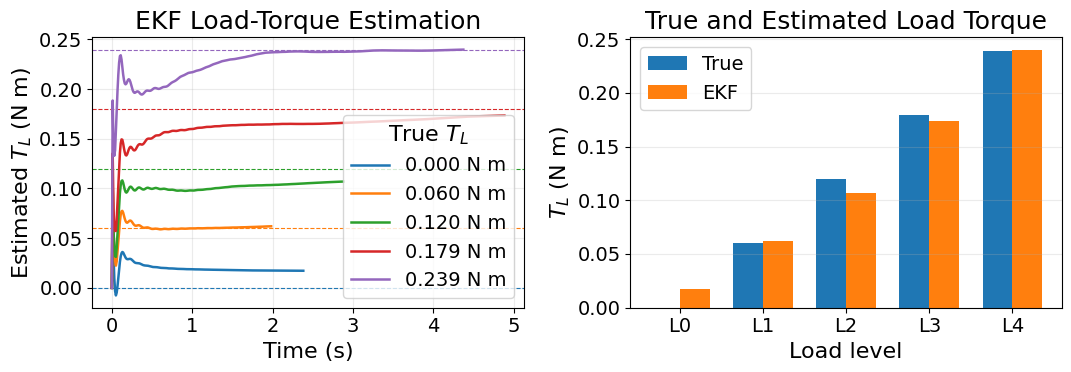

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for load, (time_r, history) in zip(test_loads, results_pmdc):
    axes[0].plot(time_r, history[:, 1], label=f'{true_torque[load]:.3f} N m')
    axes[0].axhline(true_torque[load], color=f'C{load}', ls='--', lw=0.8)
axes[0].set(xlabel='Time (s)', ylabel=r'Estimated $T_L$ (N m)',
            title='EKF Load-Torque Estimation')
axes[0].legend(title=r'True $T_L$');  axes[0].grid(alpha=0.25)

x_pos = np.arange(len(test_loads));  width = 0.36
axes[1].bar(x_pos - width/2, true_torque[test_loads], width, label='True')
axes[1].bar(x_pos + width/2, estimates,                width, label='EKF')
axes[1].set(xlabel='Load level', ylabel=r'$T_L$ (N m)',
            title='True and Estimated Load Torque',
            xticks=x_pos, xticklabels=[f'L{i}' for i in test_loads])
axes[1].legend();  axes[1].grid(axis='y', alpha=0.25)
plt.tight_layout();  plt.show()

# CMU VAH12 SOC Estimation


### Data Loading and Preparation

In [3]:
# Required packages and imports
%pip install -q numpy pandas scipy matplotlib

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.interpolate import PchipInterpolator
from scipy.optimize import least_squares


# Google Drive is assumed to be mounted already.
data_dir = Path(
    '/content/drive/MyDrive/PHM Practice/Datasets/Battery_CMU'
)
test_cell = 'VAH12'

data_path = data_dir / f'{test_cell}.csv'
impedance_path = data_dir / f'{test_cell}_impedance.csv'

if not data_path.exists():
    raise FileNotFoundError(data_path)
if not impedance_path.exists():
    raise FileNotFoundError(impedance_path)

battery = pd.read_csv(data_path)
impedance = pd.read_csv(impedance_path)

battery.columns = (
    battery.columns.str.strip()
    .str.replace(' ', '_', regex=False)
)
impedance.columns = (
    impedance.columns.str.strip()
    .str.replace(' ', '_', regex=False)
)


# Reconstruction of sequential cycles
local_cycle = battery['cycleNumber'].astype(int)
segment = battery['Ns'].astype(int)
new_cycle = (
    local_cycle.ne(local_cycle.shift())
    | (segment.eq(0) & segment.shift().ne(0))
)
new_cycle.iloc[0] = True
battery['global_cycle'] = new_cycle.cumsum().astype(int)


# Identification of mission and RPT cycles
cycle_summary = battery.groupby('global_cycle').agg(
    start_time=('time_s', 'min'),
    end_time=('time_s', 'max'),
    capacity_ah=(
        'QDischarge_mA_h', lambda x: x.max() / 1000
    )
)
cycle_summary['duration_h'] = (
    cycle_summary['end_time'] - cycle_summary['start_time']
) / 3600

segment_presence = pd.crosstab(
    battery['global_cycle'], segment
).gt(0)
has_2 = segment_presence.get(
    2, pd.Series(False, index=segment_presence.index)
)
has_7 = segment_presence.get(
    7, pd.Series(False, index=segment_presence.index)
)
rpt_mask = (
    has_2 & has_7
    & (cycle_summary['duration_h'] > 5)
    & (cycle_summary['capacity_ah'] > 1.5)
)

rpt_cycles = cycle_summary.index[rpt_mask].to_numpy()
mission_cycles = cycle_summary.index[~rpt_mask].to_numpy()

if len(rpt_cycles) == 0:
    raise ValueError('No RPT cycle was identified')

initial_capacity = cycle_summary.loc[
    rpt_cycles[0], 'capacity_ah'
]

print(f'Cell                 = {test_cell}')
print(f'Number of cycles     = {battery.global_cycle.nunique()}')
print(f'Number of RPT cycles = {len(rpt_cycles)}')
print(f'Initial capacity     = {initial_capacity:.3f} Ah')


Cell                 = VAH12
Number of cycles     = 2349
Number of RPT cycles = 47
Initial capacity     = 3.061 Ah


### Initial OCV–SOC Curve from the RPT

Initial RPT cycle = 1
OCV table points  = 101
SOC range         = 0.00–1.00
Initial 30 s DCIR = 0.04112–0.03159 Ω


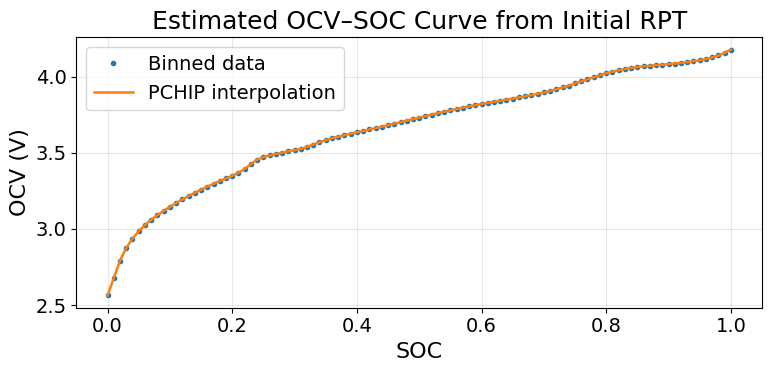

In [4]:
initial_rpt_cycle = rpt_cycles[0]
rpt = battery[
    (battery['global_cycle'] == initial_rpt_cycle)
    & battery['I_mA'].between(-800, -400)
].copy()

rpt['soc'] = (
    1 - rpt['QDischarge_mA_h']
    / (1000 * initial_capacity)
)
rpt['dod'] = 1 - rpt['soc']

r20 = impedance['20%_30_second'].iloc[0]
r60 = impedance['60%_30_second'].iloc[0]
rpt['resistance'] = np.interp(
    rpt['dod'], [0.2, 0.6], [r20, r60]
)
rpt['ocv'] = (
    rpt['Ecell_V']
    - rpt['I_mA'] * rpt['resistance'] / 1000
)
rpt['soc'] = rpt['soc'].clip(0, 1).round(2)

ocv_table = (
    rpt.groupby('soc', as_index=False)['ocv']
    .median().sort_values('soc')
)
ocv_function = PchipInterpolator(
    ocv_table['soc'], ocv_table['ocv']
)
d_ocv = ocv_function.derivative()
soc_grid = np.linspace(0, 1, 300)

print(f'Initial RPT cycle = {initial_rpt_cycle}')
print(f'OCV table points  = {len(ocv_table)}')
print(
    f'SOC range         = {ocv_table["soc"].min():.2f}–'
    f'{ocv_table["soc"].max():.2f}'
)
print(f'Initial 30 s DCIR = {r20:.5f}–{r60:.5f} Ω')

plt.figure(figsize=(8, 4))
plt.plot(
    ocv_table['soc'], ocv_table['ocv'],
    'o', markersize=3, label='Binned data'
)
plt.plot(
    soc_grid, ocv_function(soc_grid),
    label='PCHIP interpolation'
)
plt.xlabel('SOC')
plt.ylabel('OCV (V)')
plt.title('Estimated OCV–SOC Curve from Initial RPT')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### Initial Thevenin Model Parameters


Identification cycle = 2
R0   = 0.021806 Ω
R1   = 0.009628 Ω
C1   = 7800.43 F
Tau1 = 75.10 s
Voltage MAE  = 15.26 mV
Voltage RMSE = 20.95 mV


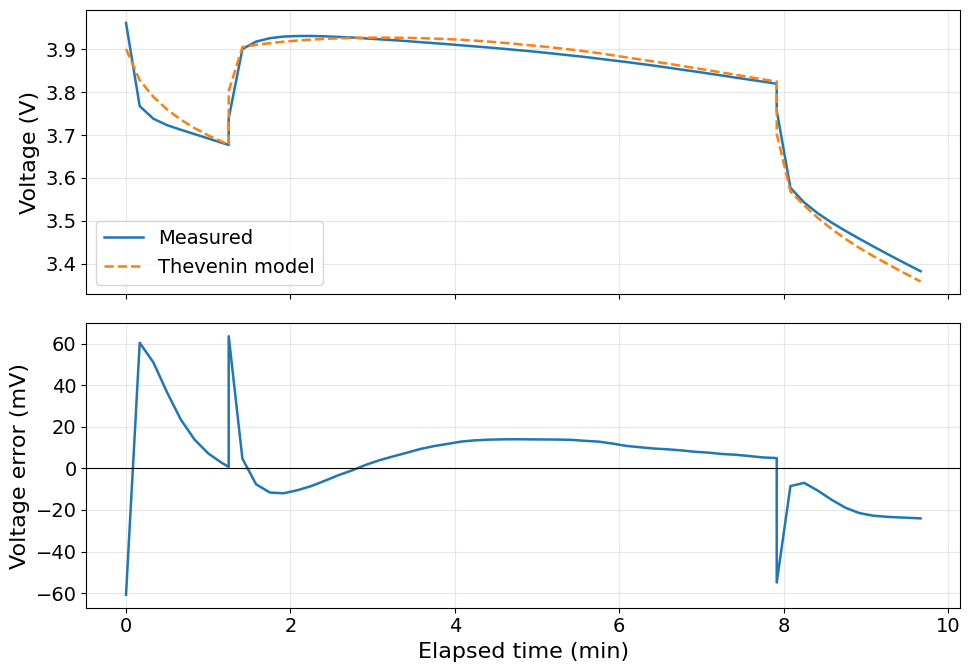

In [5]:
from scipy.optimize import least_squares

identification_cycle = mission_cycles[mission_cycles > initial_rpt_cycle][0]
identification_data = battery[(battery['global_cycle'] == identification_cycle) & battery['Ns'].isin([4, 5, 6])].sort_values('time_s')

time_ident = identification_data['time_s'].to_numpy()
voltage_ident = identification_data['Ecell_V'].to_numpy()
current_ident = -identification_data['I_mA'].to_numpy() / 1000
dt_ident = np.diff(time_ident, prepend=time_ident[0])
dt_ident[0] = np.median(dt_ident[1:])

def simulate_thevenin(parameters):
    r0, r1, tau1 = parameters
    soc = np.ones(len(time_ident))
    v1 = np.zeros(len(time_ident))
    voltage = np.zeros(len(time_ident))
    voltage[0] = ocv_function(1.0) - r0 * current_ident[0]

    for k in range(1, len(time_ident)):
        soc[k] = np.clip(soc[k-1] - current_ident[k-1] * dt_ident[k] / (3600 * initial_capacity), 0, 1)
        decay = np.exp(-dt_ident[k] / tau1)
        v1[k] = decay * v1[k-1] + r1 * (1 - decay) * current_ident[k-1]
        voltage[k] = ocv_function(soc[k]) - r0 * current_ident[k] - v1[k]

    return voltage, soc, v1

def voltage_residual(parameters):
    return simulate_thevenin(parameters)[0] - voltage_ident

r0_initial = np.mean([impedance['20%_1_second'].iloc[0], impedance['60%_1_second'].iloc[0]])
r1_initial = np.mean([impedance['20%_30_second'].iloc[0] - impedance['20%_1_second'].iloc[0], impedance['60%_30_second'].iloc[0] - impedance['60%_1_second'].iloc[0]])

result = least_squares(voltage_residual, x0=[r0_initial, r1_initial, 30], bounds=([0.001, 0.001, 1], [0.100, 0.100, 1000]))

r0, r1, tau1 = result.x
c1 = tau1 / r1
voltage_model, soc_model, v1_model = simulate_thevenin(result.x)
voltage_error = voltage_model - voltage_ident
voltage_mae = np.mean(np.abs(voltage_error))
voltage_rmse = np.sqrt(np.mean(voltage_error**2))
elapsed_ident = (time_ident - time_ident[0]) / 60

print(f'Identification cycle = {identification_cycle}')
print(f'R0   = {r0:.6f} Ω')
print(f'R1   = {r1:.6f} Ω')
print(f'C1   = {c1:.2f} F')
print(f'Tau1 = {tau1:.2f} s')
print(f'Voltage MAE  = {1000 * voltage_mae:.2f} mV')
print(f'Voltage RMSE = {1000 * voltage_rmse:.2f} mV')

fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

axes[0].plot(elapsed_ident, voltage_ident, label='Measured')
axes[0].plot(elapsed_ident, voltage_model, '--', label='Thevenin model')
axes[0].set_ylabel('Voltage (V)')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(elapsed_ident, 1000 * voltage_error)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_xlabel('Elapsed time (min)')
axes[1].set_ylabel('Voltage error (mV)')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Validation of Identified Thevenin Model

Validation cycle = 3
Voltage MAE  = 14.12 mV
Voltage RMSE = 20.01 mV


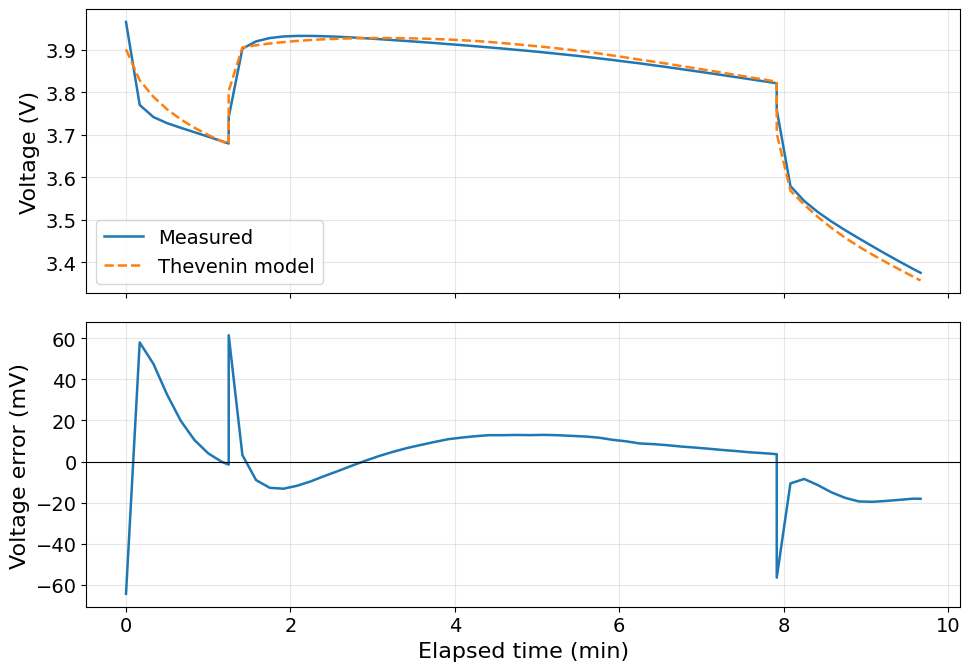

In [6]:
validation_cycle = mission_cycles[mission_cycles > identification_cycle][0]
validation_data = battery[(battery['global_cycle'] == validation_cycle) & battery['Ns'].isin([4, 5, 6])].sort_values('time_s')

time_val = validation_data['time_s'].to_numpy()
voltage_val = validation_data['Ecell_V'].to_numpy()
current_val = -validation_data['I_mA'].to_numpy() / 1000
dt_val = np.diff(time_val, prepend=time_val[0])
dt_val[0] = np.median(dt_val[1:])

soc_val = np.ones(len(time_val))
v1_val = np.zeros(len(time_val))
voltage_pred = np.zeros(len(time_val))
voltage_pred[0] = ocv_function(1.0) - r0 * current_val[0]

for k in range(1, len(time_val)):
    soc_val[k] = np.clip(soc_val[k-1] - current_val[k-1] * dt_val[k] / (3600 * initial_capacity), 0, 1)
    decay = np.exp(-dt_val[k] / tau1)
    v1_val[k] = decay * v1_val[k-1] + r1 * (1 - decay) * current_val[k-1]
    voltage_pred[k] = ocv_function(soc_val[k]) - r0 * current_val[k] - v1_val[k]

voltage_error_val = voltage_pred - voltage_val
voltage_mae_val = np.mean(np.abs(voltage_error_val))
voltage_rmse_val = np.sqrt(np.mean(voltage_error_val**2))
elapsed_val = (time_val - time_val[0]) / 60

print(f'Validation cycle = {validation_cycle}')
print(f'Voltage MAE  = {1000 * voltage_mae_val:.2f} mV')
print(f'Voltage RMSE = {1000 * voltage_rmse_val:.2f} mV')

fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

axes[0].plot(elapsed_val, voltage_val, label='Measured')
axes[0].plot(elapsed_val, voltage_pred, '--', label='Thevenin model')
axes[0].set_ylabel('Voltage (V)')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(elapsed_val, 1000 * voltage_error_val)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_xlabel('Elapsed time (min)')
axes[1].set_ylabel('Voltage error (mV)')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### SOC Estimation Using EKF

EKF cycle = 4
Coulomb counting RMSE = 10.00%
EKF SOC MAE           = 1.52%
EKF SOC RMSE          = 2.61%


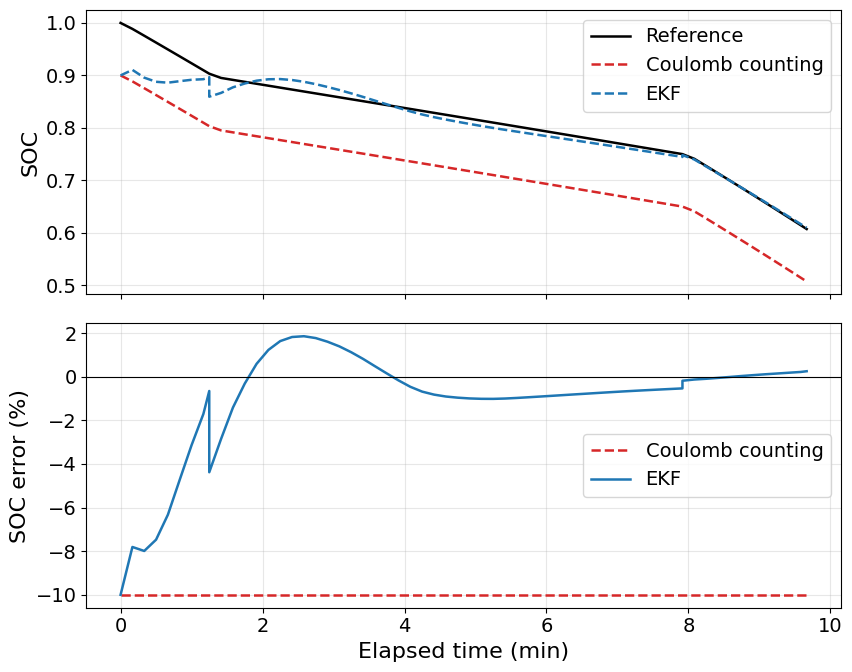

In [7]:
ekf_cycle = 4  # mission_cycles[mission_cycles > validation_cycle][0]
ekf_data = battery[(battery['global_cycle'] == ekf_cycle) & battery['Ns'].isin([4, 5, 6])].sort_values('time_s')

t = ekf_data['time_s'].to_numpy()
i = -ekf_data['I_mA'].to_numpy() / 1000
v = ekf_data['Ecell_V'].to_numpy()
dt = np.diff(t, prepend=t[0])
dt[0] = np.median(dt[1:])

n = len(t)
soc_ref = np.ones(n)
soc_est = np.zeros(n)
v1_est = np.zeros(n)
soc_est[0] = 0.9

P = np.diag([0.1**2, 0.05**2])
Qx = np.diag([1e-6, 1e-5])
R = voltage_rmse_val**2

for k in range(1, n):
    soc_ref[k] = soc_ref[k-1] - i[k-1] * dt[k] / (3600 * initial_capacity)

    a = np.exp(-dt[k] / tau1)
    soc_pred = np.clip(soc_est[k-1] - i[k-1] * dt[k] / (3600 * initial_capacity), 0, 1)
    v1_pred = a * v1_est[k-1] + r1 * (1 - a) * i[k-1]
    x_pred = np.array([soc_pred, v1_pred])

    F = np.diag([1, a])
    P_pred = F @ P @ F.T + Qx

    H = np.array([[np.asarray(d_ocv(soc_pred)).item(), -1]])
    voltage_pred = ocv_function(soc_pred) - r0 * i[k] - v1_pred
    S = (H @ P_pred @ H.T).item() + R
    K = P_pred @ H.T / S

    x = x_pred + K[:, 0] * (v[k] - voltage_pred)
    soc_est[k] = np.clip(x[0], 0, 1)
    v1_est[k] = x[1]

    A = np.eye(2) - K @ H
    P = A @ P_pred @ A.T + K * R @ K.T

soc_cc = soc_ref - 0.1
error_cc = soc_cc - soc_ref
error_ekf = soc_est - soc_ref
elapsed = (t - t[0]) / 60

mae_ekf = 100 * np.mean(np.abs(error_ekf))
rmse_ekf = 100 * np.sqrt(np.mean(error_ekf**2))
rmse_cc = 100 * np.sqrt(np.mean(error_cc**2))

print(f'EKF cycle = {ekf_cycle}')
print(f'Coulomb counting RMSE = {rmse_cc:.2f}%')
print(f'EKF SOC MAE           = {mae_ekf:.2f}%')
print(f'EKF SOC RMSE          = {rmse_ekf:.2f}%')

fig, axes = plt.subplots(2, 1, figsize=(9, 7), sharex=True)

axes[0].plot(elapsed, soc_ref, 'k', label='Reference')
axes[0].plot(elapsed, soc_cc, '--', color='tab:red', label='Coulomb counting')
axes[0].plot(elapsed, soc_est, '--', color='tab:blue', label='EKF')
axes[0].set_ylabel('SOC')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(elapsed, 100 * error_cc, '--', color='tab:red', label='Coulomb counting')
axes[1].plot(elapsed, 100 * error_ekf, color='tab:blue', label='EKF')
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_xlabel('Elapsed time (min)')
axes[1].set_ylabel('SOC error (%)')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()